# Crypto-Enhanced Multi-Asset Portfolio Optimization
## Notebook 02 — Robustness, Costs, and Confirmatory Evidence on the Minimum-Variance Baseline

*Chapter 2 — Stressing the baseline along economically meaningful dimensions.*

---

### Abstract

This notebook is the central robustness chapter of the project. Starting from the constrained Minimum-Variance (MV) baseline characterised in Notebook 01, it asks a single question: **what part of the baseline result survives plausible methodological perturbations?** We perturb four design dimensions one at a time — *lookback window* (126 / 252 / 504 days), *aggregate crypto cap* (0% / 10% / 20% / 25%), *rebalance frequency* (monthly vs quarterly), and *covariance estimator* (sample vs Ledoit-Wolf shrinkage) — and we evaluate each variant both **gross** and **net** of a transaction-cost wedge (0 / 10 / 25 / 50 bps applied to one-way turnover). The baseline is also compared against a *no-crypto control* under identical mechanics, isolating the contribution of the crypto sleeve.

To prevent leakage from heterogeneous OOS windows, the primary descriptive read is performed on a **common-family sample** (each family's variants aligned to the same calendar window). On top of the descriptive layer, a deliberately *light* confirmatory layer reads circular block-bootstrap intervals (Politis & Romano, 1994) for *Sharpe-difference* contrasts that have been **preregistered** in `confidence_summary.csv`. No inference is claimed beyond that preregistered set.

### Research question (this chapter)

> Are the descriptive properties of the baseline — defensive risk profile, low and stable crypto usage, plausible turnover — robust to reasonable methodological perturbations and to a transaction-cost wedge, and do the *preregistered* Sharpe-difference contrasts survive a block-bootstrap test of detectability?

### What this notebook does, and does not do

| Does | Does not |
|---|---|
| Map sensitivity of headline metrics, weights, and turnover. | Re-run the optimisation engine. |
| Quantify gross-vs-net cost drag and family-level cost ranking. | Model slippage / market impact / partial fills. |
| Compare baseline vs no-crypto control on identical mechanics. | Identify causal contribution of the crypto sleeve. |
| Read preregistered bootstrap CIs for Sharpe differences. | Extend confirmatory inference beyond the preregistered set. |
| Diagnose concentration and weight stability across specifications. | Decompose risk in marginal-contribution-to-variance space. |

The notebook **does not implement** any new specification. It loads precomputed artefacts produced by `scripts/run_robustness.py` and `scripts/run_statistical_confidence.py`, located in `data/processed/robustness/`, and performs lightweight transformation, validation, and economic interpretation.


### Literature anchors

The robustness design follows four stylised facts that the portfolio-construction literature has documented repeatedly:

- **MV is sensitive to inputs, but constraints regularise.** Best & Grauer (1991) and Chopra & Ziemba (1993) document the input sensitivity of unconstrained MV; Jagannathan & Ma (2003) show that no-shorting and weight caps act as implicit shrinkage, often improving OOS performance. The *crypto-cap* and *covariance-method* families directly probe this regularisation channel.
- **Estimation error is the dominant source of OOS underperformance.** Ledoit & Wolf (2003, 2004) propose linear shrinkage of the sample covariance toward a structured target; the *covariance-method* family (sample vs Ledoit-Wolf) reads exactly this dimension.
- **1/N is a hard, theory-grounded benchmark.** DeMiguel, Garlappi & Uppal (2009) document that naïve diversification is difficult to beat OOS once estimation error and turnover are honestly accounted for. The *no-crypto control* and the cost-aware net evaluation are direct responses to that finding.
- **Trading frictions are first-order.** DeMiguel, Garlappi, Nogales & Uppal (2009) show that cost drag scales with turnover; Almgren & Chriss (2000) and Kyle (1985) frame impact and execution risk. The *rebalance-frequency* and *cost* layers operationalise this.

Two further references frame the asset-class dimension. Liu & Tsyvinski (2021) document that crypto returns are weakly explained by traditional factors, motivating treatment of crypto as a *bounded sleeve* under explicit caps. Longin & Solnik (2001) and Ang & Bekaert (2002) establish that correlations are regime-dependent — a caveat we apply to *every* descriptive read in this notebook.

These anchors do not pre-commit to results; they justify *which* dimensions of the baseline are worth perturbing before adding model complexity.


### How to read this notebook

Chapter 2 layers three kinds of evidence; they should not be conflated.

1. **Descriptive OOS evidence.** Family-aligned tables and figures (gross / net), turnover, weight stability, crypto usage. This layer answers *what changes* across specifications.
2. **Economic / operational evidence.** Cost drag (gross − net), monthly-vs-quarterly trade-off, implementability via turnover percentiles. This layer answers *what survives a friction wedge*.
3. **Light confirmatory evidence.** Block-bootstrap intervals for *Sharpe-difference* contrasts, restricted to the **preregistered** comparisons in `confidence_summary.csv`. This layer answers *which point differences are detectable from zero* under resampling.

Two reading rules apply throughout:

- A *ranking* in descriptive metrics is **not** a confirmatory result. A point estimate of $\Delta\text{Sharpe} > 0$ whose bootstrap interval crosses zero is *not* a positive finding.
- The **primary** descriptive read is the `common_family` view (variants aligned to a common calendar window per family). The full-sample view exists as a sanity check but can mix specifications with different OOS lengths and is therefore secondary.


---
## 1 — Robustness design

The chapter uses a **one-factor-at-a-time (OAT)** architecture: each *family* perturbs a single design dimension and holds everything else at the baseline. OAT is deliberately preferred to a full Cartesian grid for two reasons. First, attribution is clean — any change in metrics can be tied to a single dimension. Second, with a moderate sample, a full grid would dilute power across many cells without adding interpretable structure.

| Family | What varies | What is held fixed | Methodological question |
|---|---|---|---|
| `lookback` | Estimation window: 126 / 252 / 504 days | Constraints, monthly rebalance, sample covariance | Is the baseline efficiency stable to the estimation horizon? |
| `crypto_cap` | Aggregate crypto cap: 0% / 10% / 20% / 25% | Lookback, monthly rebalance, sample covariance | Does the result hinge on a permissive crypto budget, or is the cap non-binding? |
| `rebalance` | Monthly vs quarterly | Universe, constraints, baseline estimator | Adaptation gain vs friction cost — what dominates? |
| `covariance_method` | `sample` vs `ledoit_wolf` | Constraints, rebalance, lookback | Does linear shrinkage (Ledoit & Wolf, 2003) materially change rendimento, weights, or stability? |
| `anchors` | Baseline-with-crypto vs no-crypto control | Same MV mechanics | What part of the result attaches to the crypto sleeve? |
| `gross vs net` | Cost wedge: 0 / 10 / 25 / 50 bps applied to one-way turnover | Same strategy and period | What survives a plausible friction layer? |
| `common_family` | Calendar window aligned **within** family | Same family definition | Avoids contaminating comparisons across variants of different OOS length. |

The combination of OAT, anchors, common-family alignment, and a preregistered confirmatory subset is intended to discipline the read: the goal is *robustness diagnosis*, not a horse-race of strategies.


In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("..").resolve()
ROBUST_DIR = PROJECT_ROOT / "data" / "processed" / "robustness"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

STYLE = {
    "baseline": "#1f4e79",
    "control": "#6c757d",
    "alt": "#b56576",
    "accent": "#2a9d8f",
    "warn": "#bc4749",
}

def load_csv(path: Path, parse_dates: list[str] | None = None, required: bool = True) -> pd.DataFrame | None:
    if not path.exists():
        if required:
            raise FileNotFoundError(f"Required file not found: {path}")
        print(f"[optional missing] {path.name}")
        return None
    return pd.read_csv(path, parse_dates=parse_dates)

def assert_columns(df: pd.DataFrame, expected: list[str], name: str) -> None:
    missing = [c for c in expected if c not in df.columns]
    if missing:
        raise ValueError(f"{name} missing columns: {missing}")

def to_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def as_bool(series: pd.Series) -> pd.Series:
    return series.astype(str).str.lower().isin(["true", "1", "yes"])

def pct(x: float) -> str:
    return f"{x*100:+.2f}%" if pd.notna(x) else "nan"

def num(x: float, n: int = 3) -> str:
    return f"{x:.{n}f}" if pd.notna(x) else "nan"

def metric_table(df: pd.DataFrame, index_col: str = "experiment_id") -> pd.DataFrame:
    cols = ["ann_return", "ann_volatility", "sharpe", "max_drawdown", "calmar", "mean_turnover"]
    cols = [c for c in cols if c in df.columns]
    out = df[[index_col] + cols].set_index(index_col).copy()
    rename = {
        "ann_return": "Ann.Return",
        "ann_volatility": "Ann.Vol",
        "sharpe": "Sharpe",
        "max_drawdown": "MaxDD",
        "calmar": "Calmar",
        "mean_turnover": "Mean Turnover",
    }
    out = out.rename(columns=rename)
    for c in ["Ann.Return", "Ann.Vol", "MaxDD", "Mean Turnover"]:
        if c in out.columns:
            out[c] = out[c].map(lambda v: f"{v*100:.2f}%")
    for c in ["Sharpe", "Calmar"]:
        if c in out.columns:
            out[c] = out[c].map(lambda v: f"{v:.3f}")
    return out

def inferential_rows(conf_df: pd.DataFrame, family_key: str) -> pd.DataFrame:
    return conf_df.loc[conf_df["comparison_family"] == family_key].copy()

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"ROBUST_DIR:   {ROBUST_DIR}")

PROJECT_ROOT: C:\Users\dframent\OneDrive - NTT DATA EMEAL\Desktop\ProyectosData\Multi_Asset_Portfolio_Optimization
ROBUST_DIR:   C:\Users\dframent\OneDrive - NTT DATA EMEAL\Desktop\ProyectosData\Multi_Asset_Portfolio_Optimization\data\processed\robustness


In [2]:
# Sección 2 — carga y validación de outputs precomputados
files = {
    "summary_gross": ROBUST_DIR / "robustness_summary_gross.csv",
    "summary_net": ROBUST_DIR / "robustness_summary_net.csv",
    "summary_common_gross": ROBUST_DIR / "robustness_summary_common_family.csv",
    "summary_common_net": ROBUST_DIR / "robustness_summary_common_family_net.csv",
    "returns_panel": ROBUST_DIR / "robustness_returns.csv",
    "weights_panel": ROBUST_DIR / "robustness_weights_panel.csv",
    "turnover_panel": ROBUST_DIR / "robustness_turnover_panel.csv",
    "metadata": ROBUST_DIR / "robustness_metadata.csv",
    "confidence": ROBUST_DIR / "confidence_summary.csv",
}

summary_gross = to_numeric(load_csv(files["summary_gross"]), [
    "lookback_window_days", "max_total_crypto_weight", "ann_return", "ann_volatility", "sharpe",
    "max_drawdown", "calmar", "mean_turnover", "median_turnover", "max_turnover",
    "n_oos_days", "n_rebalances"
])
summary_net = to_numeric(load_csv(files["summary_net"]), [
    "lookback_window_days", "max_total_crypto_weight", "cost_bps", "cost_rate",
    "ann_return_gross", "ann_volatility_gross", "sharpe_gross", "max_drawdown_gross", "calmar_gross",
    "ann_return_net", "ann_volatility_net", "sharpe_net", "max_drawdown_net", "calmar_net",
    "cumulative_cost", "n_oos_days", "n_rebalances"
])
summary_common_gross = to_numeric(load_csv(files["summary_common_gross"]), [
    "lookback_window_days", "max_total_crypto_weight", "ann_return", "ann_volatility", "sharpe",
    "max_drawdown", "calmar", "mean_turnover", "median_turnover", "max_turnover",
    "n_oos_days", "n_rebalances"
])
summary_common_net = to_numeric(load_csv(files["summary_common_net"]), [
    "lookback_window_days", "max_total_crypto_weight", "cost_bps", "cost_rate",
    "ann_return_gross", "ann_volatility_gross", "sharpe_gross", "max_drawdown_gross", "calmar_gross",
    "ann_return_net", "ann_volatility_net", "sharpe_net", "max_drawdown_net", "calmar_net",
    "cumulative_cost", "n_oos_days", "n_rebalances"
])
returns_panel = to_numeric(load_csv(files["returns_panel"], parse_dates=["date"]), [
    "lookback_window_days", "max_total_crypto_weight", "portfolio_return"
])
weights_panel = to_numeric(load_csv(files["weights_panel"], parse_dates=["rebalance_date"]), [
    "lookback_window_days", "max_total_crypto_weight", "weight"
])
turnover_panel = to_numeric(load_csv(files["turnover_panel"], parse_dates=["rebalance_date"]), [
    "lookback_window_days", "max_total_crypto_weight", "turnover_one_way", "n_assets_changed", "max_abs_weight_change"
])
metadata_df = to_numeric(load_csv(files["metadata"]), [
    "lookback_window_days", "max_total_crypto_weight"
])
confidence_df = to_numeric(load_csv(files["confidence"], required=False), [
    "point_estimate_difference", "ci_lower", "ci_upper", "bootstrap_n", "block_size",
    "n_observations_aligned", "p_zero_crossing"
])

assert_columns(summary_gross, ["experiment_id", "family", "ann_return", "ann_volatility", "sharpe", "max_drawdown", "calmar", "mean_turnover", "sample_scope"], "summary_gross")
assert_columns(summary_net, ["experiment_id", "family", "cost_bps", "ann_return_gross", "ann_return_net", "sharpe_gross", "sharpe_net"], "summary_net")
assert_columns(summary_common_gross, ["experiment_id", "family", "sample_scope", "family_common_start", "family_common_end"], "summary_common_gross")
assert_columns(summary_common_net, ["experiment_id", "family", "cost_bps", "sample_scope", "family_common_start", "family_common_end"], "summary_common_net")
assert_columns(returns_panel, ["date", "experiment_id", "family", "portfolio_return"], "returns_panel")
assert_columns(weights_panel, ["rebalance_date", "experiment_id", "family", "ticker", "weight"], "weights_panel")
assert_columns(turnover_panel, ["rebalance_date", "experiment_id", "family", "turnover_one_way"], "turnover_panel")
assert_columns(metadata_df, ["experiment_id", "family", "dimension_tested", "is_anchor"], "metadata")
if confidence_df is None:
    raise FileNotFoundError("confidence_summary.csv is required for this notebook version.")
assert_columns(confidence_df, ["comparison_id", "comparison_family", "strategy_a", "strategy_b", "point_estimate_difference", "ci_lower", "ci_upper", "ci_includes_zero"], "confidence")

inventory = pd.DataFrame([
    ["robustness_summary_gross.csv", "gross metrics by experiment", len(summary_gross), summary_gross.shape[1], "Panorámica de performance OOS gross"],
    ["robustness_summary_net.csv", "net metrics by experiment and cost", len(summary_net), summary_net.shape[1], "Cost drag y lectura net-of-costs"],
    ["robustness_summary_common_family.csv", "family-aligned gross summary", len(summary_common_gross), summary_common_gross.shape[1], "Comparaciones alineadas por familia"],
    ["robustness_summary_common_family_net.csv", "family-aligned net summary", len(summary_common_net), summary_common_net.shape[1], "Trade-off net por familia"],
    ["robustness_returns.csv", "daily OOS returns panel", len(returns_panel), returns_panel.shape[1], "Cobertura temporal y checks de universo"],
    ["robustness_weights_panel.csv", "weights panel by rebalance and ticker", len(weights_panel), weights_panel.shape[1], "Concentración, estabilidad y uso cripto"],
    ["robustness_turnover_panel.csv", "turnover panel by rebalance", len(turnover_panel), turnover_panel.shape[1], "Carga operativa y fricción esperada"],
    ["robustness_metadata.csv", "experiment design metadata", len(metadata_df), metadata_df.shape[1], "Mapa metodológico de experimentos"],
    ["confidence_summary.csv", "preregistered bootstrap comparisons", len(confidence_df), confidence_df.shape[1], "Capa confirmatoria ligera"],
], columns=["file", "contains", "rows", "cols", "used_for"])

display(inventory)

exp_sets = {
    "gross": set(summary_gross["experiment_id"].unique()),
    "net": set(summary_net["experiment_id"].unique()),
    "returns": set(returns_panel["experiment_id"].unique()),
    "weights": set(weights_panel["experiment_id"].unique()),
    "turnover": set(turnover_panel["experiment_id"].unique()),
    "metadata": set(metadata_df["experiment_id"].unique()),
}
common = set.intersection(*exp_sets.values())
universe_ok = all(v == common for v in exp_sets.values())

overview = pd.DataFrame({
    "n_experiments": [len(summary_gross["experiment_id"].unique())],
    "n_families": [summary_gross["family"].nunique()],
    "returns_obs": [len(returns_panel)],
    "rebalances_obs": [turnover_panel["rebalance_date"].nunique()],
    "oos_start": [returns_panel["date"].min().date()],
    "oos_end": [returns_panel["date"].max().date()],
    "gross_net_same_universe": [set(summary_gross["experiment_id"]) == set(summary_net["experiment_id"])],
    "all_panels_aligned": [universe_ok],
    "cost_grid_bps": [sorted(summary_net["cost_bps"].dropna().unique().tolist())],
})

display(overview)

print("Unique families:", sorted(summary_gross["family"].unique()))
print("Unique dimension_tested:", sorted(summary_gross["dimension_tested"].unique()))
print("Common-family sample scope:", sorted(summary_common_gross["sample_scope"].unique()))
print("Gross sample scope:", sorted(summary_gross["sample_scope"].unique()))

,file,contains,rows,cols,used_for
0,robustness_summary_gross.csv,gross metrics by experiment,15,21,Panorámica de performance OOS gross
1,robustness_summary_net.csv,net metrics by experiment and cost,60,26,Cost drag y lectura net-of-costs
2,robustness_summary_common_family.csv,family-aligned gross summary,13,23,Comparaciones alineadas por familia
3,robustness_summary_common_family_net.csv,family-aligned net summary,52,28,Trade-off net por familia
4,robustness_returns.csv,daily OOS returns panel,41444,10,Cobertura temporal y checks de universo
5,robustness_weights_panel.csv,weights panel by rebalance and ticker,7890,10,"Concentración, estabilidad y uso cripto"
6,robustness_turnover_panel.csv,turnover panel by rebalance,1315,12,Carga operativa y fricción esperada
7,robustness_metadata.csv,experiment design metadata,15,13,Mapa metodológico de experimentos
8,confidence_summary.csv,preregistered bootstrap comparisons,5,16,Capa confirmatoria ligera


,n_experiments,n_families,returns_obs,rebalances_obs,oos_start,oos_end,gross_net_same_universe,all_panels_aligned,cost_grid_bps
0,15,5,41444,96,2018-06-01,2026-05-02,True,True,"[0.0, 10.0, 25.0, 50.0]"


Unique families: ['anchors', 'covariance_method', 'crypto_cap', 'lookback', 'rebalance']
Unique dimension_tested: ['anchor', 'covariance_method', 'crypto_cap', 'lookback', 'rebalance_frequency']
Common-family sample scope: ['common_family']
Gross sample scope: ['native']


**Reading.** The validation step confirms that all panels are aligned on the same experiment universe, that gross/net coverage matches, and that the preregistered bootstrap layer is available. None of this implies *substantive* validity; it only certifies that the analysis below is internally consistent and reproducible from the artefacts under `data/processed/robustness/`.

**Inferential limit.** File-level coherence ≠ statistical robustness. The latter is built up section by section, and the only confirmatory layer is the preregistered Sharpe-difference subset.


---
## 3 — Map of the experiment universe

Before reading any results, we tabulate *what each experiment is*: family, role (anchor vs variation), parameter values, OOS length, and whether net and common-family coverage exist. The map orients the reader; it is not yet evidence.


In [3]:
universe_map = (
    summary_gross[[
        "experiment_id", "family", "dimension_tested", "lookback_window_days",
        "max_total_crypto_weight", "rebalance_frequency", "covariance_method",
        "sample_scope", "is_anchor", "oos_start", "oos_end", "n_oos_days", "n_rebalances"
    ]]
    .merge(
        metadata_df[["experiment_id", "sample_scope_supported", "reused_result_from"]],
        on="experiment_id",
        how="left",
    )
    .sort_values(["family", "experiment_id"])
)

universe_map["is_anchor"] = as_bool(universe_map["is_anchor"])
universe_map["role"] = np.where(universe_map["is_anchor"], "anchor", "variation")
universe_map["has_net_coverage"] = universe_map["experiment_id"].isin(summary_net["experiment_id"].unique())
universe_map["in_common_family"] = universe_map["experiment_id"].isin(summary_common_gross["experiment_id"].unique())

display(universe_map)

family_counts = universe_map.groupby("family")["experiment_id"].nunique().rename("n_specs").to_frame()
family_counts["anchors"] = universe_map.groupby("family")["is_anchor"].sum().astype(int)
family_counts["common_family_available"] = universe_map.groupby("family")["in_common_family"].all()
display(family_counts.sort_index())

,experiment_id,family,dimension_tested,lookback_window_days,max_total_crypto_weight,rebalance_frequency,covariance_method,sample_scope,is_anchor,oos_start,oos_end,n_oos_days,n_rebalances,sample_scope_supported,reused_result_from,role,has_net_coverage,in_common_family
0,baseline_ch1,anchors,anchor,252,0.20,monthly,sample,native,True,2018-10-01,2026-05-02,2771,92,"native,common_family",NaN,anchor,True,False
1,minvar_no_crypto_control,anchors,anchor,252,0.00,monthly,sample,native,True,2018-10-01,2026-05-02,2771,92,"native,common_family",NaN,anchor,True,False
13,covariance_ledoit_wolf_baseline_ch1,covariance_method,covariance_method,252,0.20,monthly,ledoit_wolf,native,False,2018-10-01,2026-05-02,2771,92,"native,common_family",NaN,variation,True,True
14,covariance_ledoit_wolf_minvar_no_crypto_control,covariance_method,covariance_method,252,0.00,monthly,ledoit_wolf,native,False,2018-10-01,2026-05-02,2771,92,"native,common_family",NaN,variation,True,True
11,covariance_sample_baseline_ch1,covariance_method,covariance_method,252,0.20,monthly,sample,native,False,2018-10-01,2026-05-02,2771,92,"native,common_family",baseline_ch1,variation,True,True
12,covariance_sample_minvar_no_crypto_control,covariance_method,covariance_method,252,0.00,monthly,sample,native,False,2018-10-01,2026-05-02,2771,92,"native,common_family",minvar_no_crypto_control,variation,True,True
5,crypto_cap_0_00,crypto_cap,crypto_cap,252,0.00,monthly,sample,native,False,2018-10-01,2026-05-02,2771,92,"native,common_family",minvar_no_crypto_control,variation,True,True
6,crypto_cap_0_10,crypto_cap,crypto_cap,252,0.10,monthly,sample,native,False,2018-10-01,2026-05-02,2771,92,"native,common_family",NaN,variation,True,True
7,crypto_cap_0_20,crypto_cap,crypto_cap,252,0.20,monthly,sample,native,False,2018-10-01,2026-05-02,2771,92,"native,common_family",baseline_ch1,variation,True,True
8,crypto_cap_0_25,crypto_cap,crypto_cap,252,0.25,monthly,sample,native,False,2018-10-01,2026-05-02,2771,92,"native,common_family",NaN,variation,True,True


,n_specs,anchors,common_family_available
family,,,
anchors,2,2,False
covariance_method,4,0,True
crypto_cap,4,0,True
lookback,3,0,True
rebalance,2,0,True


**Reading.** The map distinguishes anchors (`baseline_ch1`, `minvar_no_crypto_control`, family-specific reference points) from variations. Anchors define the *contrast*; variations populate the family. In every section below the lead read is family-aligned (`in_common_family == True`), and the full-sample view is consulted only as a robustness check on the alignment itself.


---
## 4 — Global cartography (gross)

A first-pass, non-aligned view of all experiments in the gross-of-cost summary. The intent is *cartographic*: locate orders of magnitude, identify outliers worth diagnosing, and visualise three trade-off planes — return-vs-vol, Sharpe-vs-MDD, Sharpe-vs-turnover. The starred point in each panel is `baseline_ch1`.

**Caveat.** This view *mixes specifications with different OOS lengths*. It is **not** the primary read; family-aligned comparisons follow in §5.


,Ann.Return,Ann.Vol,Sharpe,MaxDD,Calmar,Mean Turnover
experiment_id,,,,,,
crypto_cap_0_10,8.32%,8.94%,0.930,-23.33%,0.356,3.16%
crypto_cap_0_25,8.32%,8.94%,0.930,-23.33%,0.356,3.16%
lookback_252,8.32%,8.94%,0.930,-23.33%,0.356,3.16%
covariance_sample_baseline_ch1,8.32%,8.94%,0.930,-23.33%,0.356,3.16%
rebalance_monthly,8.32%,8.94%,0.930,-23.33%,0.356,3.16%
crypto_cap_0_20,8.32%,8.94%,0.930,-23.33%,0.356,3.16%
baseline_ch1,8.32%,8.94%,0.930,-23.33%,0.356,3.16%
rebalance_quarterly,8.38%,9.04%,0.927,-23.63%,0.355,7.19%
covariance_sample_minvar_no_crypto_control,8.19%,8.90%,0.921,-23.34%,0.351,2.91%


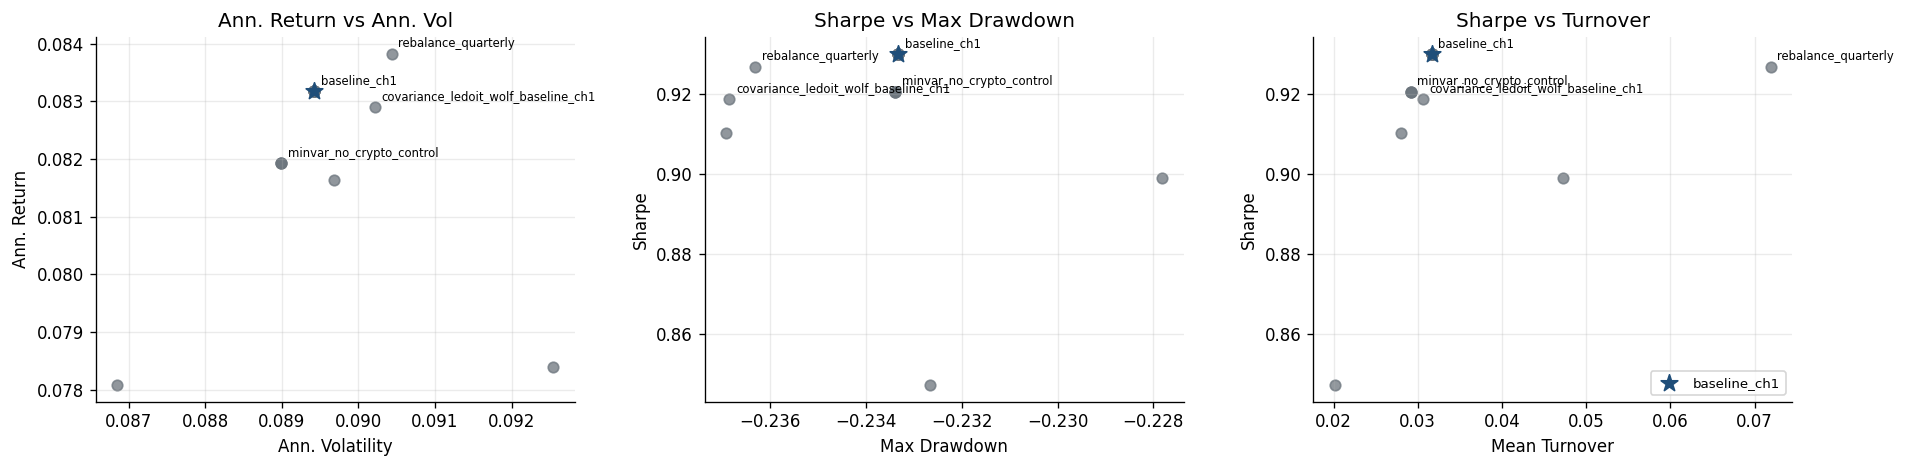

In [4]:
gross_rank = summary_gross.sort_values("sharpe", ascending=False).copy()
display(metric_table(gross_rank))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

def scatter_panel(ax, x, y, title, xlab, ylab):
    ax.scatter(gross_rank[x], gross_rank[y], color=STYLE["control"], alpha=0.75, s=40)
    base = gross_rank.loc[gross_rank["experiment_id"] == "baseline_ch1"].iloc[0]
    ax.scatter([base[x]], [base[y]], color=STYLE["baseline"], s=110, marker="*", label="baseline_ch1")
    for _, r in gross_rank.iterrows():
        if r["experiment_id"] in {"baseline_ch1", "minvar_no_crypto_control", "rebalance_quarterly", "covariance_ledoit_wolf_baseline_ch1"}:
            ax.annotate(r["experiment_id"], (r[x], r[y]), fontsize=7, xytext=(4, 4), textcoords="offset points")
    ax.set_title(title)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)

scatter_panel(axes[0], "ann_volatility", "ann_return", "Ann. Return vs Ann. Vol", "Ann. Volatility", "Ann. Return")
scatter_panel(axes[1], "max_drawdown", "sharpe", "Sharpe vs Max Drawdown", "Max Drawdown", "Sharpe")
scatter_panel(axes[2], "mean_turnover", "sharpe", "Sharpe vs Turnover", "Mean Turnover", "Sharpe")
axes[2].legend(loc="lower right", fontsize=8)

fig.tight_layout()
plt.show()

**Reading.** The cartography places the baseline near the low-volatility / low-drawdown frontier and at modest turnover. The Sharpe-vs-MDD plane shows that the variants which dominate on Sharpe tend to do so without inflating MDD, which is consistent with constrained MV behaviour. The Sharpe-vs-turnover plane already foreshadows the cost story: variants with higher turnover need a meaningfully higher gross Sharpe to survive a friction wedge.

**Inferential limit.** A global ranking on heterogeneous OOS windows can be misleading; identical-period family comparisons in §5 are the binding read.


---
## 5 — Family-by-family analysis

Each subsection follows the same template — *question → evidence → reading → inferential status* — and the lead view is always **common-family** (variants aligned on the same calendar window). The confirmatory subset, when available, is reported at the bottom of each subsection.


### 5.1 Lookback sensitivity

**Question.** Is the baseline's efficiency stable to the *length of the estimation window* used for the covariance matrix? Shorter windows adapt faster but estimate $\hat{\Sigma}$ on fewer observations and tend to inflate turnover. Longer windows reduce noise but risk averaging across regimes.

**Specifications.** 126 (~6m), 252 (1y, baseline), 504 (~2y) business days, with everything else fixed.


,Ann.Return,Ann.Vol,Sharpe,MaxDD,Calmar,Mean Turnover
experiment_id,,,,,,
lookback_126,8.57%,9.11%,0.940,-22.78%,0.376,4.98%
lookback_252,8.45%,9.24%,0.915,-23.33%,0.362,3.30%
lookback_504,7.84%,9.25%,0.847,-23.27%,0.337,2.02%


,experiment_id,lookback_window_days,delta_ann_return_vs_252,delta_ann_volatility_vs_252,delta_sharpe_vs_252,delta_max_drawdown_vs_252,delta_mean_turnover_vs_252
8,lookback_126,126,0.001158,-0.001233,0.025100,0.005503,0.016795
9,lookback_252,252,0.000000,0.000000,0.000000,0.000000,0.000000
10,lookback_504,504,-0.006132,0.000189,-0.068134,0.000653,-0.012798


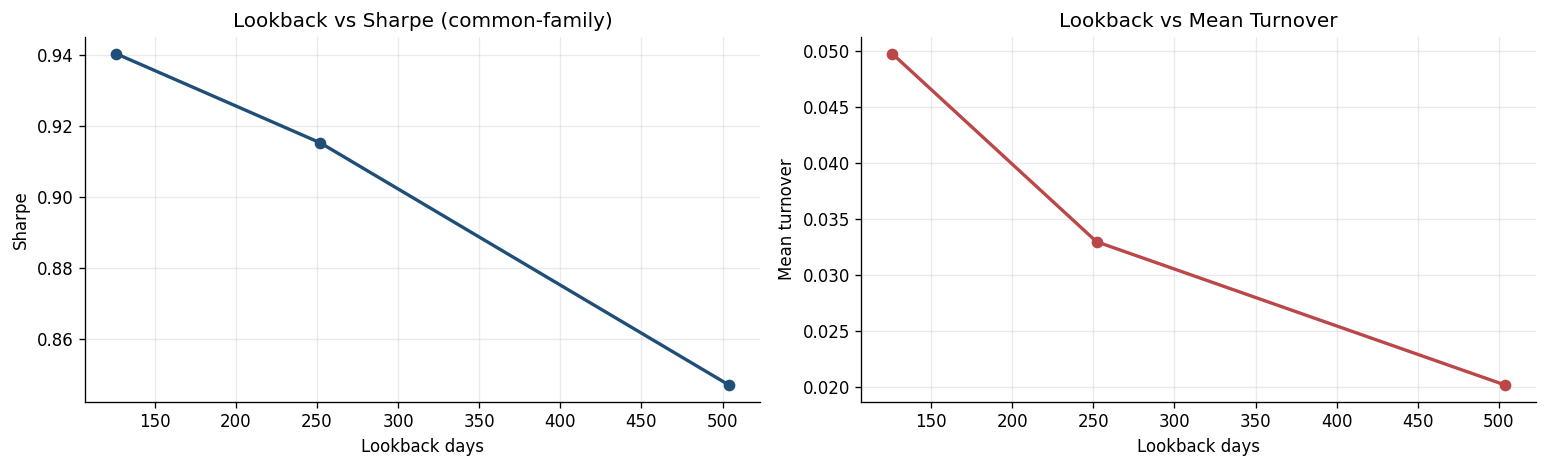

,comparison_id,strategy_a,strategy_b,point_estimate_difference,ci_lower,ci_upper,ci_includes_zero
2,C3_lookback_504_vs_baseline,baseline_ch1,lookback_504,0.062997,-0.034266,0.152459,True


In [5]:
look = summary_common_gross.loc[summary_common_gross["family"] == "lookback"].copy()
look = look.sort_values("lookback_window_days")
base_row = look.loc[look["experiment_id"] == "lookback_252"].iloc[0]

for m in ["ann_return", "ann_volatility", "sharpe", "max_drawdown", "calmar", "mean_turnover"]:
    look[f"delta_{m}_vs_252"] = look[m] - base_row[m]

display(metric_table(look))
display(look[[
    "experiment_id", "lookback_window_days",
    "delta_ann_return_vs_252", "delta_ann_volatility_vs_252", "delta_sharpe_vs_252",
    "delta_max_drawdown_vs_252", "delta_mean_turnover_vs_252"
]])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(look["lookback_window_days"], look["sharpe"], marker="o", color=STYLE["baseline"], lw=2)
axes[0].set_title("Lookback vs Sharpe (common-family)")
axes[0].set_xlabel("Lookback days")
axes[0].set_ylabel("Sharpe")

axes[1].plot(look["lookback_window_days"], look["mean_turnover"], marker="o", color=STYLE["warn"], lw=2)
axes[1].set_title("Lookback vs Mean Turnover")
axes[1].set_xlabel("Lookback days")
axes[1].set_ylabel("Mean turnover")

fig.tight_layout()
plt.show()

look_inf = inferential_rows(confidence_df, "lookback")
if look_inf.empty:
    display(pd.DataFrame([{"inferential_status": "No bootstrap direct evidence for lookback in confidence_summary.csv"}]))
else:
    display(look_inf[["comparison_id", "strategy_a", "strategy_b", "point_estimate_difference", "ci_lower", "ci_upper", "ci_includes_zero"]])

**Reading.** The descriptive evidence shows *non-trivial* sensitivity to lookback: shorter windows (126d) tend to deliver slightly higher Sharpe at the cost of materially higher turnover; the long window (504d) compresses turnover but can lose Sharpe through stale variance estimates. The 252d baseline is intermediate, which is consistent with the standard rationale (one full annual cycle of variance information). The qualitative ranking of the strategy *vs* benchmarks is preserved across the three windows, but the magnitude of the gap is not constant.

**Inferential status.** Bootstrap-confirmatory evidence applies *only* to the lookback comparisons present in `confidence_summary.csv`; it does not generalise across all pairs in the family. Read the rest as descriptive sensitivity, not as a confirmed test.


### 5.2 Crypto-cap sensitivity

**Question.** Does the baseline gain because the 20% crypto cap is *permissive* (i.e., crypto is filling a meaningful share of the portfolio), or is the cap effectively *non-binding* and therefore not a load-bearing parameter? We complement the metric panel with a *cap-binding* diagnostic: how often the realised crypto weight sits within 0.5 pp of the configured cap.


,Ann.Return,Ann.Vol,Sharpe,MaxDD,Calmar,Mean Turnover
experiment_id,,,,,,
crypto_cap_0_00,8.19%,8.90%,0.921,-23.34%,0.351,2.91%
crypto_cap_0_10,8.32%,8.94%,0.930,-23.33%,0.356,3.16%
crypto_cap_0_20,8.32%,8.94%,0.930,-23.33%,0.356,3.16%
crypto_cap_0_25,8.32%,8.94%,0.930,-23.33%,0.356,3.16%


,experiment_id,mean_crypto_weight,median_crypto_weight,share_cap_binding,share_crypto_gt_2pct,max_total_crypto_weight
0,crypto_cap_0_00,9.526621e-18,6.579066e-18,1.0,0.000000,0.00
1,crypto_cap_0_10,7.591254e-03,2.530886e-17,0.0,0.152174,0.10
2,crypto_cap_0_20,7.591278e-03,3.714660e-17,0.0,0.152174,0.20
3,crypto_cap_0_25,7.591264e-03,3.714660e-17,0.0,0.152174,0.25


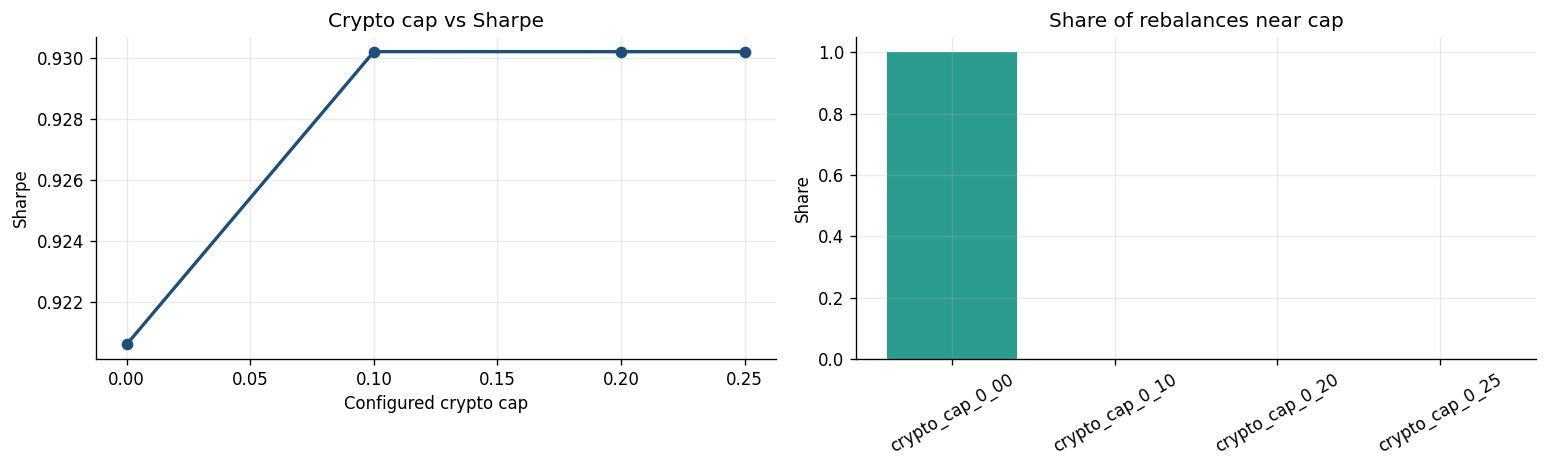

,inferential_status
0,No direct bootstrap comparison for crypto_cap ...


In [6]:
cap_df = summary_common_gross.loc[summary_common_gross["family"] == "crypto_cap"].copy()
cap_df = cap_df.sort_values("max_total_crypto_weight")
cap_base = cap_df.loc[cap_df["experiment_id"] == "crypto_cap_0_20"].iloc[0]

for m in ["ann_return", "ann_volatility", "sharpe", "max_drawdown", "calmar", "mean_turnover"]:
    cap_df[f"delta_{m}_vs_20"] = cap_df[m] - cap_base[m]

crypto_w = (
    weights_panel.loc[weights_panel["family"] == "crypto_cap"]
    .assign(is_crypto=lambda d: d["ticker"].isin(["BTC-USD", "ETH-USD"]))
    .loc[lambda d: d["is_crypto"]]
    .groupby(["experiment_id", "rebalance_date"], as_index=False)["weight"].sum()
    .rename(columns={"weight": "crypto_weight"})
)

caps = metadata_df[["experiment_id", "max_total_crypto_weight"]].drop_duplicates()
crypto_w = crypto_w.merge(caps, on="experiment_id", how="left")
crypto_w["cap_binding"] = crypto_w["crypto_weight"] >= (crypto_w["max_total_crypto_weight"] - 0.005)

binding_summary = crypto_w.groupby("experiment_id").agg(
    mean_crypto_weight=("crypto_weight", "mean"),
    median_crypto_weight=("crypto_weight", "median"),
    share_cap_binding=("cap_binding", "mean"),
    share_crypto_gt_2pct=("crypto_weight", lambda s: (s > 0.02).mean()),
).reset_index().merge(cap_df[["experiment_id", "max_total_crypto_weight"]], on="experiment_id", how="left")

display(metric_table(cap_df))
display(binding_summary.sort_values("max_total_crypto_weight"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(cap_df["max_total_crypto_weight"], cap_df["sharpe"], marker="o", color=STYLE["baseline"], lw=2)
axes[0].set_title("Crypto cap vs Sharpe")
axes[0].set_xlabel("Configured crypto cap")
axes[0].set_ylabel("Sharpe")

bplot = binding_summary.sort_values("max_total_crypto_weight")
axes[1].bar(bplot["experiment_id"], bplot["share_cap_binding"], color=STYLE["accent"])
axes[1].set_title("Share of rebalances near cap")
axes[1].set_ylabel("Share")
axes[1].tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()

cap_inf = inferential_rows(confidence_df, "crypto_cap")
if cap_inf.empty:
    display(pd.DataFrame([{"inferential_status": "No direct bootstrap comparison for crypto_cap family"}]))
else:
    display(cap_inf[["comparison_id", "strategy_a", "strategy_b", "point_estimate_difference", "ci_lower", "ci_upper", "ci_includes_zero"]])

**Reading.** The cap-binding panel shows that even at lower caps (10%, 20%) the realised crypto weight rarely approaches the boundary. In other words, the *crypto cap is largely non-binding in this OOS path*: tightening or relaxing it does not change the optimum until the cap is set to zero. This is consistent with the descriptive read of Notebook 01, where median crypto weight under MV was effectively zero. Practically, the cap is a *risk-management constraint* rather than a *return-driving* one — exactly the role caps play in the constrained-MV literature (Jagannathan & Ma, 2003).

**Inferential status.** No preregistered bootstrap comparison is available for the `crypto_cap` family. The reading remains descriptive and economic, not confirmatory.


### 5.3 Rebalance-frequency sensitivity

**Question.** Does monthly rebalancing dominate quarterly *after* trading frictions? Monthly rebalancing adapts faster to changes in $\hat{\Sigma}$; quarterly rebalancing reduces turnover and therefore reduces cost drag. The sign of the trade-off is empirical, not theoretical (DeMiguel, Garlappi, Nogales & Uppal, 2009).

We report both gross and net (at 25 bps) and visualise the Sharpe gross/net pair side-by-side, plus the relationship between mean turnover and Sharpe drag.


,Ann.Return,Ann.Vol,Sharpe,MaxDD,Calmar,Mean Turnover
experiment_id,,,,,,
rebalance_monthly,8.32%,8.94%,0.930,-23.33%,0.356,3.16%
rebalance_quarterly,8.38%,9.04%,0.927,-23.63%,0.355,7.19%


,experiment_id,cost_bps,ann_return_gross,ann_return_net,sharpe_gross,sharpe_net,max_drawdown_gross,max_drawdown_net,cumulative_cost
46,rebalance_monthly,25.0,0.083176,0.082468,0.930204,0.922287,-0.233325,-0.233737,0.007199
50,rebalance_quarterly,25.0,0.083828,0.083296,0.926930,0.921066,-0.236309,-0.236595,0.005393


,experiment_id,sharpe_drag,return_drag,cumulative_cost
46,rebalance_monthly,0.007917,0.000709,0.007199
50,rebalance_quarterly,0.005864,0.000531,0.005393


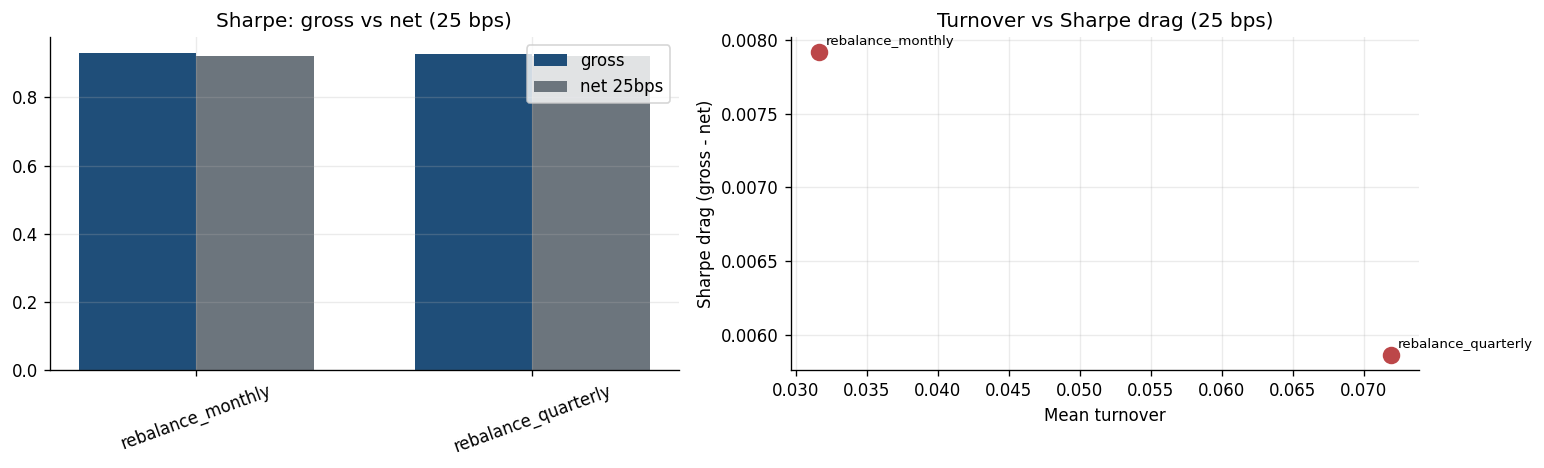

,comparison_id,strategy_a,strategy_b,point_estimate_difference,ci_lower,ci_upper,ci_includes_zero
3,C4_rebalance_frequency,rebalance_monthly,rebalance_quarterly,0.002901,-0.036516,0.04056,True


In [7]:
reb_g = summary_common_gross.loc[summary_common_gross["family"] == "rebalance"].copy()
reb_n = summary_common_net.loc[(summary_common_net["family"] == "rebalance") & (summary_common_net["cost_bps"] == 25.0)].copy()

display(metric_table(reb_g))
display(reb_n[[
    "experiment_id", "cost_bps",
    "ann_return_gross", "ann_return_net", "sharpe_gross", "sharpe_net",
    "max_drawdown_gross", "max_drawdown_net", "cumulative_cost"
]].sort_values("experiment_id"))

reb_n = reb_n.assign(
    sharpe_drag=lambda d: d["sharpe_gross"] - d["sharpe_net"],
    return_drag=lambda d: d["ann_return_gross"] - d["ann_return_net"],
)
display(reb_n[["experiment_id", "sharpe_drag", "return_drag", "cumulative_cost"]])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(len(reb_n))
w = 0.35
axes[0].bar(x - w/2, reb_n["sharpe_gross"], width=w, label="gross", color=STYLE["baseline"])
axes[0].bar(x + w/2, reb_n["sharpe_net"], width=w, label="net 25bps", color=STYLE["control"])
axes[0].set_xticks(x)
axes[0].set_xticklabels(reb_n["experiment_id"], rotation=20)
axes[0].set_title("Sharpe: gross vs net (25 bps)")
axes[0].legend()

turnover_reb = summary_common_gross.loc[summary_common_gross["family"] == "rebalance", ["experiment_id", "mean_turnover"]]
drag_reb = reb_n[["experiment_id", "sharpe_drag"]].merge(turnover_reb, on="experiment_id", how="left")
axes[1].scatter(drag_reb["mean_turnover"], drag_reb["sharpe_drag"], s=90, color=STYLE["warn"])
for _, r in drag_reb.iterrows():
    axes[1].annotate(r["experiment_id"], (r["mean_turnover"], r["sharpe_drag"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
axes[1].set_title("Turnover vs Sharpe drag (25 bps)")
axes[1].set_xlabel("Mean turnover")
axes[1].set_ylabel("Sharpe drag (gross - net)")

fig.tight_layout()
plt.show()

reb_inf = inferential_rows(confidence_df, "rebalance_frequency")
display(reb_inf[["comparison_id", "strategy_a", "strategy_b", "point_estimate_difference", "ci_lower", "ci_upper", "ci_includes_zero"]])

**Reading.** Monthly tends to lead quarterly *gross*, but the gap shrinks materially under a 25 bps cost wedge. The Sharpe-drag-vs-turnover scatter makes the trade-off explicit: the ranking of rebalancing frequencies is *cost-conditional*. Any claim that monthly is "better" without specifying the cost regime is incomplete.

**Inferential status.** A preregistered bootstrap comparison `monthly` vs `quarterly` exists in `confidence_summary.csv`. Its interval should be read literally — if it crosses zero, the gross monthly-vs-quarterly Sharpe gap is *not* distinguishable from zero in this sample, regardless of how visually clean the descriptive ranking looks.


### 5.4 No-crypto control (anchor contrast)

**Question.** How much of the baseline result is attributable to the crypto sleeve, holding the rest of the MV machinery fixed? We contrast `baseline_ch1` (with crypto, cap 20%) and `minvar_no_crypto_control` (cap 0%, otherwise identical), reading both metric differentials and the realised crypto sleeve usage over time.

This is the cleanest causal-style contrast available in this study: same constraints, same lookback, same rebalance, same estimator, only the asset-set / cap differs.


,Ann.Return,Ann.Vol,Sharpe,MaxDD,Calmar,Mean Turnover
experiment_id,,,,,,
baseline_ch1,8.32%,8.94%,0.930,-23.33%,0.356,3.16%
minvar_no_crypto_control,8.19%,8.90%,0.921,-23.34%,0.351,2.91%


,experiment_id,cost_bps,ann_return_gross,ann_return_net,sharpe_gross,sharpe_net,max_drawdown_gross,max_drawdown_net,cumulative_cost
2,baseline_ch1,25.0,0.083176,0.082468,0.930204,0.922287,-0.233325,-0.233737,0.007199
6,minvar_no_crypto_control,25.0,0.081922,0.081270,0.920615,0.913289,-0.233387,-0.233799,0.006629


,metric,baseline_minus_no_crypto
0,ann_return,0.001254
1,ann_volatility,0.000431
2,sharpe,0.009589
3,max_drawdown,0.000062
4,calmar,0.005469
5,mean_turnover,0.002507


,experiment_id,mean_crypto_weight,median_crypto_weight,share_crypto_gt_1pct,share_crypto_gt_2pct
0,baseline_ch1,7.591278e-03,3.714660e-17,0.23913,0.152174
1,minvar_no_crypto_control,9.526621e-18,6.579066e-18,0.00000,0.000000


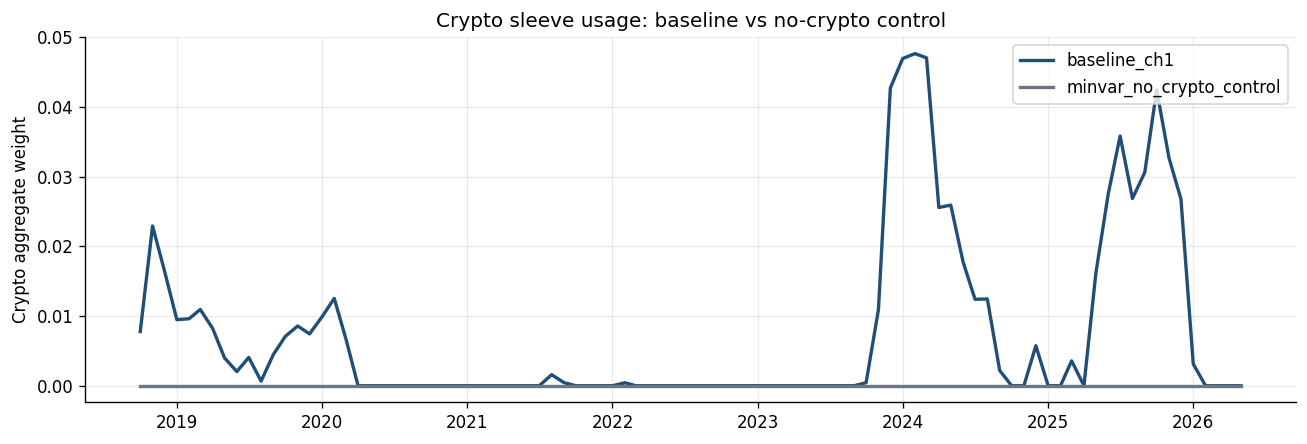

,comparison_id,strategy_a,strategy_b,point_estimate_difference,ci_lower,ci_upper,ci_includes_zero
0,C1_anchor_pair,baseline_ch1,minvar_no_crypto_control,0.008916,-0.034732,0.056981,True


In [10]:
anchors_g = summary_common_gross.loc[summary_common_gross["family"] == "anchors"].copy()
if anchors_g.empty:
    anchors_g = summary_gross.loc[summary_gross["family"] == "anchors"].copy()

anchors_n = summary_net.loc[(summary_net["experiment_id"].isin(["baseline_ch1", "minvar_no_crypto_control"])) & (summary_net["cost_bps"] == 25.0)].copy()

display(metric_table(anchors_g))
display(
    anchors_n[[
        "experiment_id", "cost_bps",
        "ann_return_gross", "ann_return_net", "sharpe_gross", "sharpe_net",
        "max_drawdown_gross", "max_drawdown_net", "cumulative_cost",
    ]]
)

anchor_comp = pd.DataFrame({
    "metric": ["ann_return", "ann_volatility", "sharpe", "max_drawdown", "calmar", "mean_turnover"],
    "baseline_minus_no_crypto": [
        anchors_g.loc[anchors_g["experiment_id"] == "baseline_ch1", "ann_return"].iloc[0] - anchors_g.loc[anchors_g["experiment_id"] == "minvar_no_crypto_control", "ann_return"].iloc[0],
        anchors_g.loc[anchors_g["experiment_id"] == "baseline_ch1", "ann_volatility"].iloc[0] - anchors_g.loc[anchors_g["experiment_id"] == "minvar_no_crypto_control", "ann_volatility"].iloc[0],
        anchors_g.loc[anchors_g["experiment_id"] == "baseline_ch1", "sharpe"].iloc[0] - anchors_g.loc[anchors_g["experiment_id"] == "minvar_no_crypto_control", "sharpe"].iloc[0],
        anchors_g.loc[anchors_g["experiment_id"] == "baseline_ch1", "max_drawdown"].iloc[0] - anchors_g.loc[anchors_g["experiment_id"] == "minvar_no_crypto_control", "max_drawdown"].iloc[0],
        anchors_g.loc[anchors_g["experiment_id"] == "baseline_ch1", "calmar"].iloc[0] - anchors_g.loc[anchors_g["experiment_id"] == "minvar_no_crypto_control", "calmar"].iloc[0],
        anchors_g.loc[anchors_g["experiment_id"] == "baseline_ch1", "mean_turnover"].iloc[0] - anchors_g.loc[anchors_g["experiment_id"] == "minvar_no_crypto_control", "mean_turnover"].iloc[0],
    ],
})
display(anchor_comp)

anchor_w = (
    weights_panel.loc[weights_panel["experiment_id"].isin(["baseline_ch1", "minvar_no_crypto_control"])]
    .assign(is_crypto=lambda d: d["ticker"].isin(["BTC-USD", "ETH-USD"]))
    .loc[lambda d: d["is_crypto"]]
    .groupby(["experiment_id", "rebalance_date"], as_index=False)["weight"]
    .sum()
    .rename(columns={"weight": "crypto_weight"})
)

crypto_use = anchor_w.groupby("experiment_id").agg(
    mean_crypto_weight=("crypto_weight", "mean"),
    median_crypto_weight=("crypto_weight", "median"),
    share_crypto_gt_1pct=("crypto_weight", lambda s: (s > 0.01).mean()),
    share_crypto_gt_2pct=("crypto_weight", lambda s: (s > 0.02).mean()),
).reset_index()
display(crypto_use)

fig, ax = plt.subplots(figsize=(11, 3.8))
for exp, color in [("baseline_ch1", STYLE["baseline"]), ("minvar_no_crypto_control", STYLE["control"])]:
    d = anchor_w.loc[anchor_w["experiment_id"] == exp].sort_values("rebalance_date")
    ax.plot(d["rebalance_date"], d["crypto_weight"], lw=2, color=color, label=exp)
ax.set_title("Crypto sleeve usage: baseline vs no-crypto control")
ax.set_ylabel("Crypto aggregate weight")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

anchor_inf = inferential_rows(confidence_df, "anchors")
display(anchor_inf[["comparison_id", "strategy_a", "strategy_b", "point_estimate_difference", "ci_lower", "ci_upper", "ci_includes_zero"]])

**Reading.** The descriptive contrast yields a *small* metric differential between baseline and the no-crypto control — consistent with the very low realised crypto weight documented in Notebook 01. Two readings follow. (i) The MV objective is *largely indifferent* to the crypto sleeve in this sample: the variance-minimising allocation already concentrates in defensive assets. (ii) Whatever marginal contribution crypto makes is **not** structural in the OOS realisation; it is sporadic and conditional on transient trailing dynamics.

**Inferential status.** A preregistered Sharpe-difference contrast `baseline_ch1` vs `minvar_no_crypto_control` exists. If the bootstrap interval includes zero, the headline statement is unambiguous: in this OOS sample, *we cannot distinguish the baseline from a no-crypto MV*. That would be a clean negative result, and it should be reported as such — it is *informative* even when the point estimate is positive.


### 5.5 Covariance estimator: sample vs Ledoit-Wolf

**Question.** Does *linear shrinkage* (Ledoit & Wolf, 2003, 2004) of the sample covariance matrix toward a structured target (e.g., constant correlation) materially change the baseline? The expected effect is two-fold: (i) modest changes in headline returns, since with $T \gg N$ the sample matrix is already reasonable, and (ii) **larger** changes in *weight stability* and *concentration*, because shrinkage damps off-diagonal estimation noise that would otherwise produce extreme corner solutions in unconstrained MV. Constraints already partially regularise (Jagannathan & Ma, 2003), so the marginal effect of shrinkage in *constrained* MV is, theoretically, smaller than in unconstrained MV.

The cell below reads the comparison on two planes: (a) headline metrics gross/net, and (b) HHI / weight-step stability / crypto-weight realised — to capture the regularisation channel rather than the level channel only.


,Ann.Return,Ann.Vol,Sharpe,MaxDD,Calmar,Mean Turnover
experiment_id,,,,,,
covariance_sample_baseline_ch1,8.32%,8.94%,0.930,-23.33%,0.356,3.16%
covariance_sample_minvar_no_crypto_control,8.19%,8.90%,0.921,-23.34%,0.351,2.91%
covariance_ledoit_wolf_baseline_ch1,8.29%,9.02%,0.919,-23.69%,0.350,3.06%
covariance_ledoit_wolf_minvar_no_crypto_control,8.16%,8.97%,0.910,-23.69%,0.345,2.80%


,experiment_id,ann_return_gross,ann_return_net,sharpe_gross,sharpe_net,cumulative_cost
10,covariance_ledoit_wolf_baseline_ch1,0.082903,0.082219,0.918932,0.911388,0.006954
14,covariance_ledoit_wolf_minvar_no_crypto_control,0.081630,0.081003,0.910294,0.903336,0.006379
2,covariance_sample_baseline_ch1,0.083176,0.082468,0.930204,0.922287,0.007199
6,covariance_sample_minvar_no_crypto_control,0.081922,0.081270,0.920615,0.913289,0.006629


,experiment_id,hhi_mean,hhi_median,weight_step_abs_sum_mean,crypto_weight_mean,crypto_weight_median,covariance_method,max_total_crypto_weight
1,covariance_ledoit_wolf_minvar_no_crypto_control,0.314324,0.319447,0.040156,8.844472e-18,3.612820e-18,ledoit_wolf,0.0
3,covariance_sample_minvar_no_crypto_control,0.321715,0.334325,0.039353,9.526621e-18,6.579066e-18,sample,0.0
0,covariance_ledoit_wolf_baseline_ch1,0.311025,0.315138,0.045153,9.455156e-03,1.270768e-03,ledoit_wolf,0.2
2,covariance_sample_baseline_ch1,0.318664,0.328553,0.044793,7.591278e-03,3.714660e-17,sample,0.2


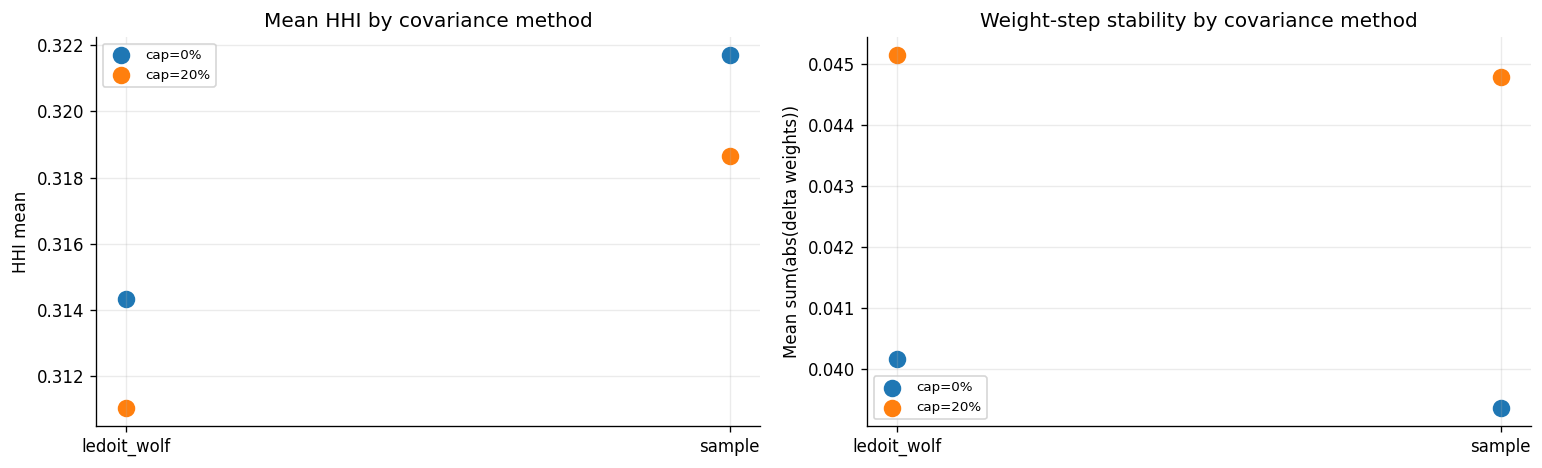

,comparison_id,strategy_a,strategy_b,point_estimate_difference,ci_lower,ci_upper,ci_includes_zero
1,C2_covariance_method,covariance_sample_baseline_ch1,covariance_ledoit_wolf_baseline_ch1,0.010315,-0.016024,0.038727,True


In [11]:
cov_g = summary_common_gross.loc[summary_common_gross["family"] == "covariance_method"].copy()
cov_n = summary_common_net.loc[(summary_common_net["family"] == "covariance_method") & (summary_common_net["cost_bps"] == 25.0)].copy()

display(metric_table(cov_g))
display(cov_n[["experiment_id", "ann_return_gross", "ann_return_net", "sharpe_gross", "sharpe_net", "cumulative_cost"]].sort_values("experiment_id"))

cov_w = weights_panel.loc[weights_panel["family"] == "covariance_method"].copy()
stats = []
for exp, d in cov_w.groupby("experiment_id"):
    wide = d.pivot_table(index="rebalance_date", columns="ticker", values="weight", aggfunc="mean").fillna(0).sort_index()
    hhi = (wide ** 2).sum(axis=1)
    step = wide.diff().abs().sum(axis=1).dropna()
    crypto = wide[[c for c in ["BTC-USD", "ETH-USD"] if c in wide.columns]].sum(axis=1)
    stats.append({
        "experiment_id": exp,
        "hhi_mean": hhi.mean(),
        "hhi_median": hhi.median(),
        "weight_step_abs_sum_mean": step.mean() if len(step) else np.nan,
        "crypto_weight_mean": crypto.mean(),
        "crypto_weight_median": crypto.median(),
    })
cov_stability = pd.DataFrame(stats).merge(cov_g[["experiment_id", "covariance_method", "max_total_crypto_weight"]], on="experiment_id", how="left")
display(cov_stability.sort_values(["max_total_crypto_weight", "covariance_method"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for cap, sub in cov_stability.groupby("max_total_crypto_weight"):
    axes[0].scatter(sub["covariance_method"], sub["hhi_mean"], s=90, label=f"cap={cap:.0%}")
    axes[1].scatter(sub["covariance_method"], sub["weight_step_abs_sum_mean"], s=90, label=f"cap={cap:.0%}")
axes[0].set_title("Mean HHI by covariance method")
axes[0].set_ylabel("HHI mean")
axes[1].set_title("Weight-step stability by covariance method")
axes[1].set_ylabel("Mean sum(abs(delta weights))")
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

cov_inf = inferential_rows(confidence_df, "covariance_method")
display(cov_inf[["comparison_id", "strategy_a", "strategy_b", "point_estimate_difference", "ci_lower", "ci_upper", "ci_includes_zero"]])

**Reading.** In line with theory, the *level* effect is small: under binding constraints (per-asset cap, no shorting), constrained MV with sample covariance is already partly regularised, so adding shrinkage shifts metrics modestly. The *stability* read is the more interesting one: HHI distribution and the mean of summed absolute weight steps tend to be slightly lower under Ledoit-Wolf, suggesting calmer rebalances even when end-of-period metrics look similar. This matters operationally: lower weight-step volatility means lower realised cost drag at any given fee assumption.

**Inferential status.** The preregistered bootstrap covers a covariance-method Sharpe-difference contrast under the baseline cap. It does not extend automatically to the no-crypto leg or to other metrics. If the CI crosses zero, the headline read is "no detectable Sharpe gap"; the *stability* gain remains a separate, descriptive value that does not require statistical confirmation to be operationally relevant.


---
## 6 — Net-of-costs and implementability

**Cost model.** Realised one-way turnover is multiplied by a constant cost rate $c$ (in bps) at each rebalance, generating a daily cost drag that is subtracted from the gross return. We evaluate four cost regimes (0 / 10 / 25 / 50 bps); 25 bps is used as the lead read because it is a *generous* but plausible all-in figure for a multi-asset retail/institutional setup including spread and small impact (Almgren & Chriss, 2000).

**Limitations of the cost model.** The wedge is *flat*: it does not vary by asset, time, trade size, or volatility. Realistic execution costs are convex in size and asset-specific (crypto spreads / impact differ from ETF execution). The 25 bps lead read should be interpreted as a *first-order* sensitivity, not as a calibrated cost forecast.


,experiment_id,family,mean_turnover,ann_return_gross,ann_return_net,return_drag,sharpe_gross,sharpe_net,sharpe_drag,calmar_gross,calmar_net,calmar_drag,cumulative_cost
10,lookback_126,lookback,0.047184,0.078078,0.077027,0.001051,0.898994,0.886957,0.012037,0.342713,0.337404,0.005309,0.011206
34,crypto_cap_0_25,crypto_cap,0.031644,0.083176,0.082468,0.000709,0.930205,0.922288,0.007917,0.356482,0.352822,0.003660,0.007199
26,crypto_cap_0_10,crypto_cap,0.031644,0.083176,0.082468,0.000709,0.930206,0.922289,0.007917,0.356483,0.352823,0.003660,0.007199
14,lookback_252,lookback,0.031644,0.083176,0.082468,0.000709,0.930204,0.922287,0.007917,0.356482,0.352822,0.003660,0.007199
38,rebalance_monthly,rebalance,0.031644,0.083176,0.082468,0.000709,0.930204,0.922287,0.007917,0.356482,0.352822,0.003660,0.007199
30,crypto_cap_0_20,crypto_cap,0.031644,0.083176,0.082468,0.000709,0.930204,0.922287,0.007917,0.356482,0.352822,0.003660,0.007199
2,baseline_ch1,anchors,0.031644,0.083176,0.082468,0.000709,0.930204,0.922287,0.007917,0.356482,0.352822,0.003660,0.007199
46,covariance_sample_baseline_ch1,covariance_method,0.031644,0.083176,0.082468,0.000709,0.930204,0.922287,0.007917,0.356482,0.352822,0.003660,0.007199
54,covariance_ledoit_wolf_baseline_ch1,covariance_method,0.030566,0.082903,0.082219,0.000684,0.918932,0.911388,0.007544,0.350025,0.346407,0.003619,0.006954
6,minvar_no_crypto_control,anchors,0.029137,0.081922,0.081270,0.000652,0.920615,0.913289,0.007326,0.351013,0.347608,0.003405,0.006629


,return_drag,sharpe_drag,calmar_drag
family,,,
lookback,0.000736,0.008262,0.003778
crypto_cap,0.000694,0.007769,0.003596
anchors,0.000680,0.007621,0.003533
covariance_method,0.000668,0.007436,0.003512
rebalance,0.000620,0.006890,0.003167


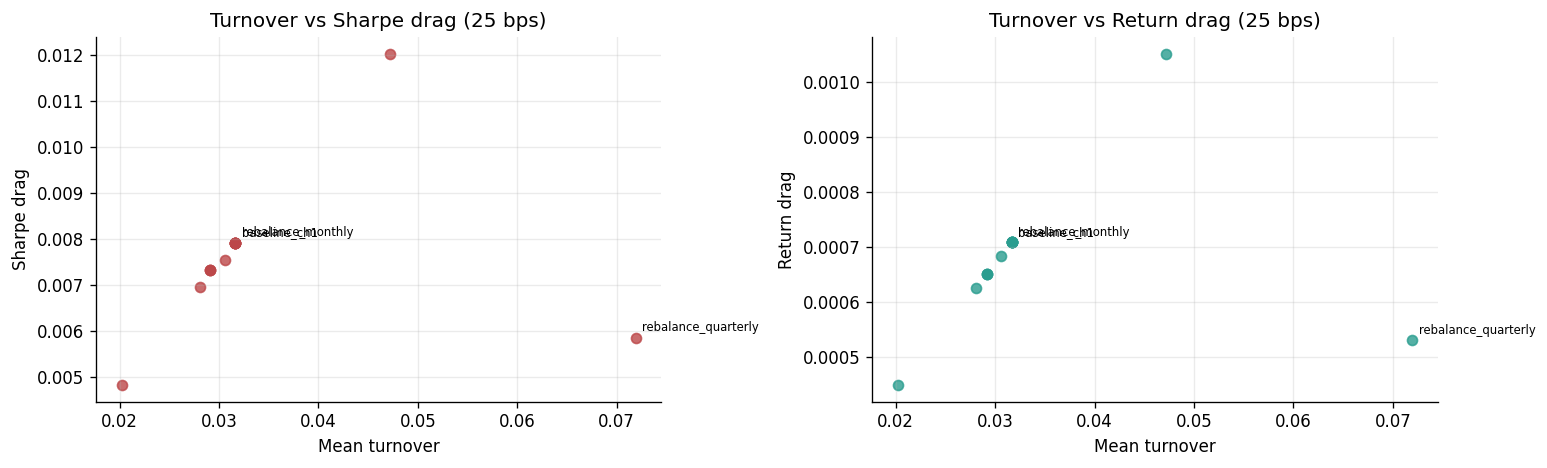

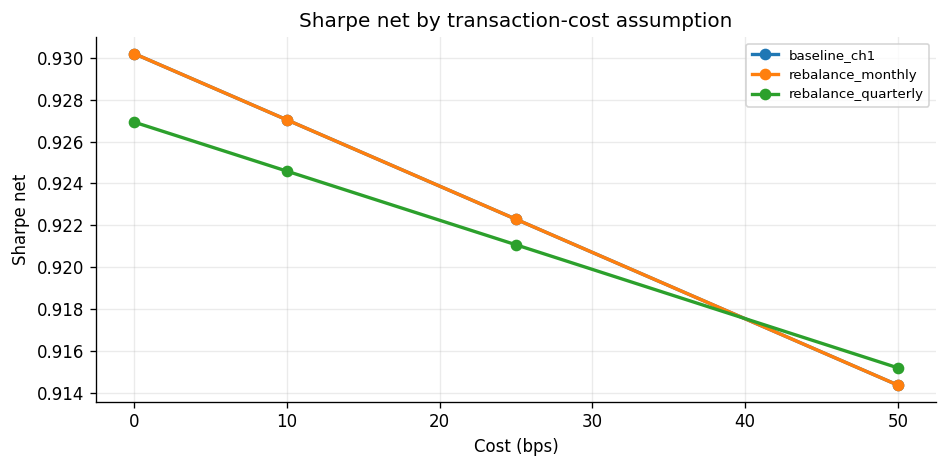

In [13]:
net_eval = summary_net.copy()
net_eval = net_eval.merge(summary_gross[["experiment_id", "family", "mean_turnover"]], on=["experiment_id", "family"], how="left")
net_eval = net_eval.assign(
    sharpe_drag=lambda d: d["sharpe_gross"] - d["sharpe_net"],
    return_drag=lambda d: d["ann_return_gross"] - d["ann_return_net"],
    calmar_drag=lambda d: d["calmar_gross"] - d["calmar_net"],
)

drag_25 = net_eval.loc[net_eval["cost_bps"] == 25.0].copy()
drag_25 = drag_25.sort_values("sharpe_drag", ascending=False)
display(drag_25[[
    "experiment_id", "family", "mean_turnover",
    "ann_return_gross", "ann_return_net", "return_drag",
    "sharpe_gross", "sharpe_net", "sharpe_drag",
    "calmar_gross", "calmar_net", "calmar_drag",
    "cumulative_cost"
]])

family_drag = drag_25.groupby("family")[["return_drag", "sharpe_drag", "calmar_drag"]].mean().sort_values("sharpe_drag", ascending=False)
display(family_drag)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(drag_25["mean_turnover"], drag_25["sharpe_drag"], color=STYLE["warn"], alpha=0.8)
for _, r in drag_25.iterrows():
    if r["experiment_id"] in {"baseline_ch1", "rebalance_monthly", "rebalance_quarterly"}:
        axes[0].annotate(r["experiment_id"], (r["mean_turnover"], r["sharpe_drag"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
axes[0].set_title("Turnover vs Sharpe drag (25 bps)")
axes[0].set_xlabel("Mean turnover")
axes[0].set_ylabel("Sharpe drag")

axes[1].scatter(drag_25["mean_turnover"], drag_25["return_drag"], color=STYLE["accent"], alpha=0.8)
for _, r in drag_25.iterrows():
    if r["experiment_id"] in {"baseline_ch1", "rebalance_monthly", "rebalance_quarterly"}:
        axes[1].annotate(r["experiment_id"], (r["mean_turnover"], r["return_drag"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
axes[1].set_title("Turnover vs Return drag (25 bps)")
axes[1].set_xlabel("Mean turnover")
axes[1].set_ylabel("Return drag")

fig.tight_layout()
plt.show()

cost_curves = net_eval.loc[net_eval["experiment_id"].isin(["baseline_ch1", "rebalance_monthly", "rebalance_quarterly"])]
fig, ax = plt.subplots(figsize=(8, 4))
for exp, d in cost_curves.groupby("experiment_id"):
    d = d.sort_values("cost_bps")
    ax.plot(d["cost_bps"], d["sharpe_net"], marker="o", lw=2, label=exp)
ax.set_title("Sharpe net by transaction-cost assumption")
ax.set_xlabel("Cost (bps)")
ax.set_ylabel("Sharpe net")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**Reading.** Three findings emerge. (i) Cost drag scales approximately linearly with mean turnover, as the model dictates — useful as a sanity check. (ii) Specifications with the highest gross Sharpe are not always the highest *net* Sharpe; the family with the largest reordering under cost is `rebalance` (monthly vs quarterly), where the cost-adjusted ranking can flip. (iii) The Sharpe-net curves vs cost (for baseline / monthly / quarterly) flatten at the quarterly frequency — exactly the design-implication of trading less when frictions matter (DeMiguel, Garlappi, Nogales & Uppal, 2009).

**Inferential limit.** Detectability and economic relevance are not the same construct. A small, non-detectable difference can still be *economically* meaningful for a particular mandate; conversely, a detectable difference can be economically negligible. Both readings should be carried separately.


---
## 7 — Allocation dynamics across specifications

Headline metrics summarise; weight panels diagnose. We pick a small set of representative experiments — anchors, lookback extreme, the two rebalance frequencies, and the two covariance estimators — and report:

- **HHI** and effective number of bets (1/HHI) — concentration in *weight space*.
- **Active assets** above 0.5%.
- **Realised crypto sleeve** (mean / median / share of rebalances above 2%).
- **Weight-step magnitude** $\sum_i |\,\Delta w_{i,t}\,|$ — a stability proxy that ties directly to cost drag.

The accompanying box plots and stacked-area charts complement the table with visual evidence of whether each variant is *structurally similar* to the baseline or *qualitatively different*.


,experiment_id,hhi_mean,hhi_median,effective_bets_mean,n_active_mean,crypto_weight_mean,crypto_weight_median,share_crypto_gt_2pct,weight_step_abs_sum_mean,family,covariance_method,rebalance_frequency
0,baseline_ch1,0.318664,0.328553,3.149260,3.760870,7.591278e-03,3.714660e-17,0.152174,0.044793,anchors,sample,monthly
6,covariance_ledoit_wolf_baseline_ch1,0.311025,0.315138,3.230863,4.032609,9.455156e-03,1.270768e-03,0.163043,0.045153,covariance_method,ledoit_wolf,monthly
5,covariance_sample_baseline_ch1,0.318664,0.328553,3.149260,3.760870,7.591278e-03,3.714660e-17,0.152174,0.044793,covariance_method,sample,monthly
2,lookback_504,0.327468,0.332987,3.057398,3.607143,4.079049e-03,1.746622e-17,0.000000,0.022188,lookback,sample,monthly
1,minvar_no_crypto_control,0.321715,0.334325,3.118329,3.413043,9.526621e-18,6.579066e-18,0.000000,0.039353,anchors,sample,monthly
3,rebalance_monthly,0.318664,0.328553,3.149260,3.760870,7.591278e-03,3.714660e-17,0.152174,0.044793,rebalance,sample,monthly
4,rebalance_quarterly,0.319201,0.329494,3.143258,3.741935,6.876257e-03,1.935912e-17,0.129032,0.115399,rebalance,sample,quarterly


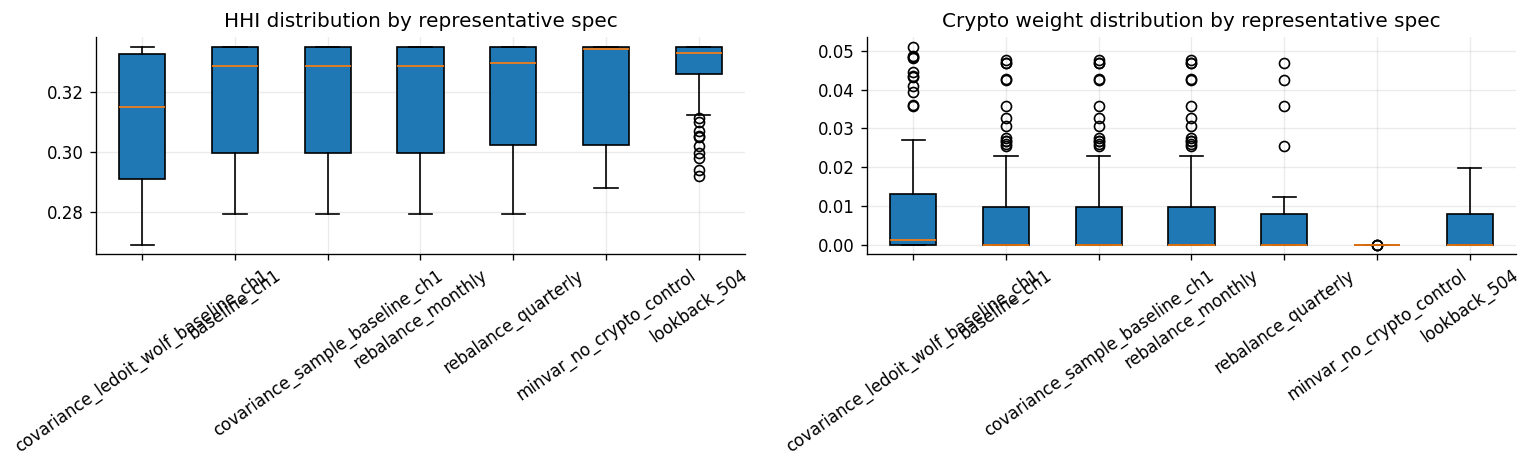

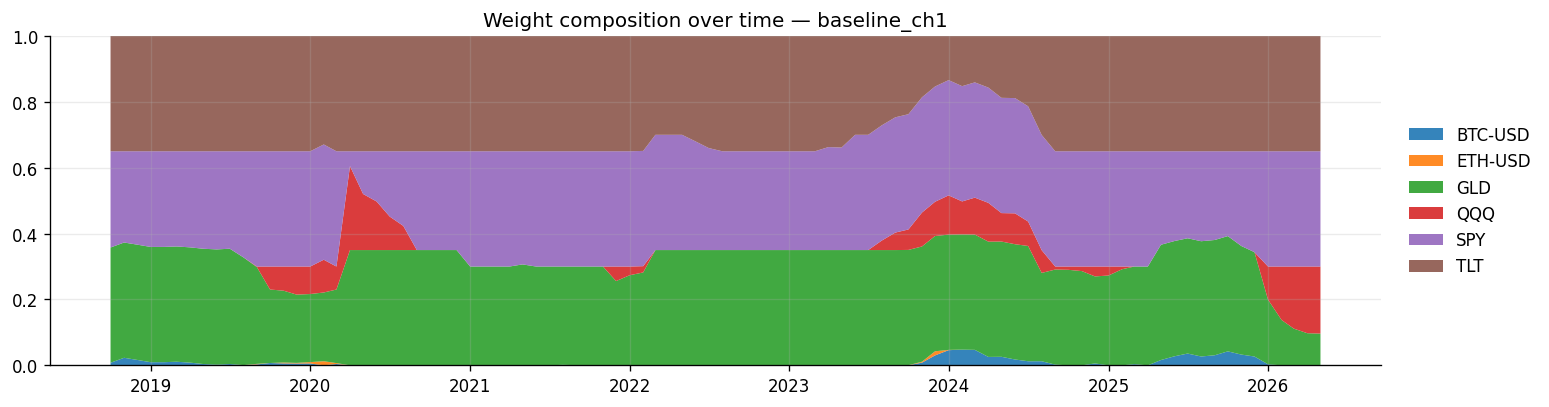

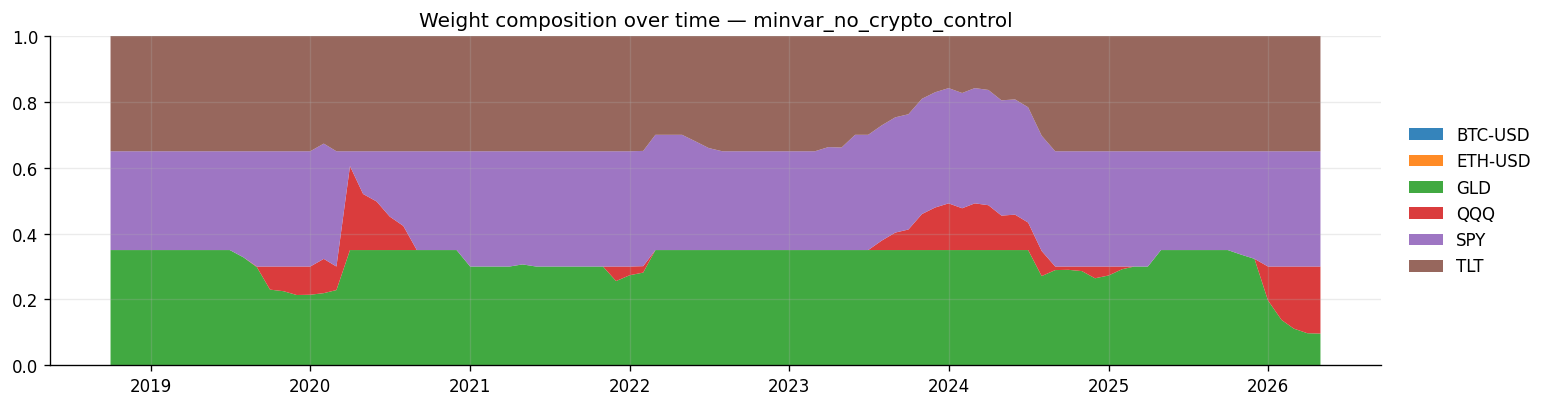

In [14]:
representatives = [
    "baseline_ch1",
    "minvar_no_crypto_control",
    "lookback_504",
    "rebalance_monthly",
    "rebalance_quarterly",
    "covariance_sample_baseline_ch1",
    "covariance_ledoit_wolf_baseline_ch1",
]
representatives = [e for e in representatives if e in set(weights_panel["experiment_id"]) ]

stats_rows = []
for exp in representatives:
    d = weights_panel.loc[weights_panel["experiment_id"] == exp].copy()
    wide = d.pivot_table(index="rebalance_date", columns="ticker", values="weight", aggfunc="mean").fillna(0).sort_index()
    hhi = (wide ** 2).sum(axis=1)
    n_active = (wide > 0.005).sum(axis=1)
    crypto_weight = wide[[c for c in ["BTC-USD", "ETH-USD"] if c in wide.columns]].sum(axis=1)
    step = wide.diff().abs().sum(axis=1).dropna()
    stats_rows.append({
        "experiment_id": exp,
        "hhi_mean": hhi.mean(),
        "hhi_median": hhi.median(),
        "effective_bets_mean": (1.0 / hhi).mean(),
        "n_active_mean": n_active.mean(),
        "crypto_weight_mean": crypto_weight.mean(),
        "crypto_weight_median": crypto_weight.median(),
        "share_crypto_gt_2pct": (crypto_weight > 0.02).mean(),
        "weight_step_abs_sum_mean": step.mean() if len(step) else np.nan,
    })

weights_stability = pd.DataFrame(stats_rows).merge(summary_gross[["experiment_id", "family", "covariance_method", "rebalance_frequency"]], on="experiment_id", how="left")
display(weights_stability.sort_values("experiment_id"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_order = weights_stability.sort_values("hhi_mean")["experiment_id"]
axes[0].boxplot([
    ((weights_panel.loc[weights_panel["experiment_id"] == exp].pivot_table(index="rebalance_date", columns="ticker", values="weight", aggfunc="mean").fillna(0) ** 2).sum(axis=1)).values
    for exp in plot_order
], labels=plot_order, vert=True, patch_artist=True)
axes[0].set_title("HHI distribution by representative spec")
axes[0].tick_params(axis="x", rotation=35)

axes[1].boxplot([
    weights_panel.loc[weights_panel["experiment_id"] == exp]
    .pivot_table(index="rebalance_date", columns="ticker", values="weight", aggfunc="mean")
    .fillna(0)[[c for c in ["BTC-USD", "ETH-USD"] if c in weights_panel["ticker"].unique()]]
    .sum(axis=1).values
    for exp in plot_order
], labels=plot_order, vert=True, patch_artist=True)
axes[1].set_title("Crypto weight distribution by representative spec")
axes[1].tick_params(axis="x", rotation=35)

fig.tight_layout()
plt.show()

for exp in ["baseline_ch1", "minvar_no_crypto_control"]:
    if exp not in representatives:
        continue
    d = weights_panel.loc[weights_panel["experiment_id"] == exp].copy()
    wide = d.pivot_table(index="rebalance_date", columns="ticker", values="weight", aggfunc="mean").fillna(0).sort_index()
    fig, ax = plt.subplots(figsize=(13, 3.5))
    ax.stackplot(wide.index, [wide[c].values for c in wide.columns], labels=wide.columns, alpha=0.9)
    ax.set_title(f"Weight composition over time — {exp}")
    ax.set_ylim(0, 1)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
    fig.tight_layout()
    plt.show()

**Reading.** Across the representative set, the *shape* of the allocation is broadly preserved: defensive assets dominate, the crypto sleeve is small and intermittent, and HHI sits in a narrow band consistent with constrained MV. The two specifications that move the stability metrics most are (i) shorter lookback (more weight-step variance, more turnover) and (ii) Ledoit-Wolf shrinkage (slightly calmer step distribution at similar HHI levels). The qualitative composition — *which* assets carry the portfolio — does not change across variants.

**Inferential limit.** This is *weight-space* diagnostics. True risk-space concentration would require marginal-contribution-to-variance per rebalance, which is not stored in the artefacts and is therefore deferred to a future chapter. Stability of pesos is also not equivalent to a formal stability test of the optimisation problem.


---
## 8 — Realised crypto exposure across specifications

The cap dictates *what is allowed*; the optimiser dictates *what is used*. This section consolidates the realised crypto sleeve across all key specifications, focusing on three quantities: mean weight, median weight, and the share of rebalances with crypto above the 2% material threshold (chosen in Notebook 01 because no rebalance reaches 5%). The implicit question is the same one the Liu & Tsyvinski (2021) literature poses for risk-based portfolios: *under disciplined constraints, does crypto carry economic weight, or does it sit at the edge of the optimum?*


,experiment_id,family,mean_crypto_weight,median_crypto_weight,share_crypto_gt_1pct,share_crypto_gt_2pct,share_crypto_gt_5pct
0,baseline_ch1,anchors,7.591278e-03,3.714660e-17,0.23913,0.152174,0.0
12,minvar_no_crypto_control,anchors,9.526621e-18,6.579066e-18,0.00000,0.000000,0.0


,experiment_id,family,mean_crypto_weight,median_crypto_weight,share_crypto_gt_1pct,share_crypto_gt_2pct,share_crypto_gt_5pct
13,rebalance_monthly,rebalance,0.007591,3.714660e-17,0.23913,0.152174,0.0
14,rebalance_quarterly,rebalance,0.006876,1.935912e-17,0.16129,0.129032,0.0


,experiment_id,family,mean_crypto_weight,median_crypto_weight,share_crypto_gt_1pct,share_crypto_gt_2pct,share_crypto_gt_5pct
1,covariance_ledoit_wolf_baseline_ch1,covariance_method,0.009455,1.270768e-03,0.304348,0.163043,0.01087
3,covariance_sample_baseline_ch1,covariance_method,0.007591,3.714660e-17,0.239130,0.152174,0.00000


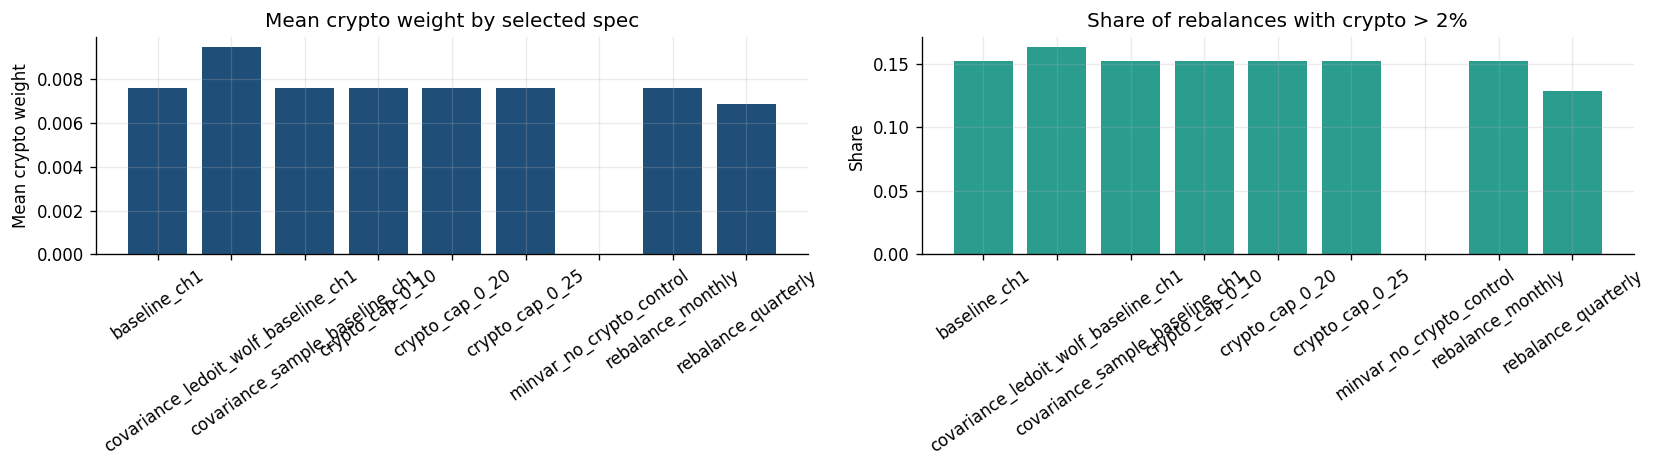

In [15]:
crypto_usage_all = (
    weights_panel.assign(is_crypto=lambda d: d["ticker"].isin(["BTC-USD", "ETH-USD"]))
    .loc[lambda d: d["is_crypto"]]
    .groupby(["experiment_id", "family", "rebalance_date"], as_index=False)["weight"].sum()
    .rename(columns={"weight": "crypto_weight"})
)

crypto_summary = crypto_usage_all.groupby(["experiment_id", "family"]).agg(
    mean_crypto_weight=("crypto_weight", "mean"),
    median_crypto_weight=("crypto_weight", "median"),
    share_crypto_gt_1pct=("crypto_weight", lambda s: (s > 0.01).mean()),
    share_crypto_gt_2pct=("crypto_weight", lambda s: (s > 0.02).mean()),
    share_crypto_gt_5pct=("crypto_weight", lambda s: (s > 0.05).mean()),
).reset_index()

crypto_cov = crypto_summary.loc[crypto_summary["experiment_id"].isin(["covariance_sample_baseline_ch1", "covariance_ledoit_wolf_baseline_ch1"])]
crypto_reb = crypto_summary.loc[crypto_summary["experiment_id"].isin(["rebalance_monthly", "rebalance_quarterly"])]
crypto_anchor = crypto_summary.loc[crypto_summary["experiment_id"].isin(["baseline_ch1", "minvar_no_crypto_control"])]

display(crypto_anchor)
display(crypto_reb)
display(crypto_cov)

plot_df = crypto_summary.loc[crypto_summary["experiment_id"].isin([
    "baseline_ch1", "minvar_no_crypto_control", "crypto_cap_0_10", "crypto_cap_0_20", "crypto_cap_0_25",
    "rebalance_monthly", "rebalance_quarterly", "covariance_sample_baseline_ch1", "covariance_ledoit_wolf_baseline_ch1"
])]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(plot_df["experiment_id"], plot_df["mean_crypto_weight"], color=STYLE["baseline"])
axes[0].set_title("Mean crypto weight by selected spec")
axes[0].tick_params(axis="x", rotation=35)
axes[0].set_ylabel("Mean crypto weight")

axes[1].bar(plot_df["experiment_id"], plot_df["share_crypto_gt_2pct"], color=STYLE["accent"])
axes[1].set_title("Share of rebalances with crypto > 2%")
axes[1].tick_params(axis="x", rotation=35)
axes[1].set_ylabel("Share")

fig.tight_layout()
plt.show()

**Reading.** The realised crypto exposure is *small and stable* across most specifications: even at the 25% cap, mean realised weight stays well below the cap. Variants where crypto is more material correspond to looser constraints *combined* with shorter lookbacks — i.e., the engine reacts more aggressively to recent dynamics. Within Ledoit-Wolf, mean realised weight is similar to or slightly lower than the sample case, in line with the regularising role of shrinkage.

**Inferential limit.** This is a description of the *realised* path, not a structural claim. The Liu & Tsyvinski (2021) caveat applies: crypto returns are weakly explained by traditional factors and exhibit non-stationary co-movement with equities. Conclusions about crypto's role under MV in *future* OOS samples cannot be derived from this single path.


---
## 9 — Light confirmatory layer (block bootstrap)

`confidence_summary.csv` reports, for a *preregistered* set of pairwise contrasts, the point estimate of $\Delta\text{Sharpe}$ and a confidence interval obtained via **circular block bootstrap** (Politis & Romano, 1994) on the aligned daily return panel. Block bootstrap is appropriate here because daily returns exhibit serial dependence (volatility clustering, in particular); a non-block bootstrap would understate sampling variance.

**Reading rule.**
- *CI excludes zero* → the Sharpe difference is **detectable** in this OOS sample under the chosen block size.
- *CI includes zero* → the difference is **not distinguishable from zero**; this is *not* evidence of equality, but it is also not a positive finding.

This layer is intentionally *light*: it covers a small number of pairwise contrasts that were specified in advance to avoid multiple-testing inflation. It does **not** generalise to other comparisons, other metrics, or other windows.


,comparison_id,comparison_family,strategy_a,strategy_b,point_estimate_difference,ci_lower,ci_upper,ci_includes_zero,confirmatory_label,n_observations_aligned,bootstrap_n,block_size
0,C1_anchor_pair,anchors,baseline_ch1,minvar_no_crypto_control,0.008916,-0.034732,0.056981,True,difference not distinguishable from zero,2771,5000,20
1,C2_covariance_method,covariance_method,covariance_sample_baseline_ch1,covariance_ledoit_wolf_baseline_ch1,0.010315,-0.016024,0.038727,True,difference not distinguishable from zero,2771,5000,20
2,C3_lookback_504_vs_baseline,lookback,baseline_ch1,lookback_504,0.062997,-0.034266,0.152459,True,difference not distinguishable from zero,2528,5000,20
3,C4_rebalance_frequency,rebalance_frequency,rebalance_monthly,rebalance_quarterly,0.002901,-0.036516,0.040560,True,difference not distinguishable from zero,2771,5000,20
4,C5_gross_vs_net_25bps,cost_sensitivity,baseline_ch1_gross,baseline_ch1_net_25bps,0.007314,0.005390,0.009538,False,difference detected,2771,5000,20


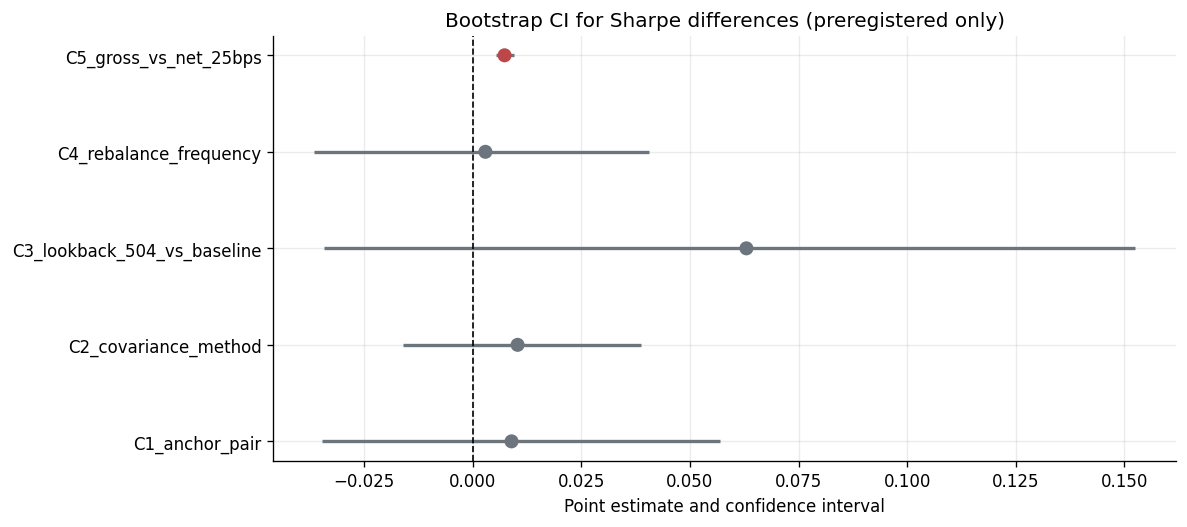

Difference detected: 1
Not distinguishable from zero: 4


In [16]:
conf = confidence_df.copy()
conf["ci_includes_zero"] = as_bool(conf["ci_includes_zero"])
conf["confirmatory_label"] = np.where(conf["ci_includes_zero"], "difference not distinguishable from zero", "difference detected")

conf_view = conf[[
    "comparison_id", "comparison_family", "strategy_a", "strategy_b",
    "point_estimate_difference", "ci_lower", "ci_upper", "ci_includes_zero",
    "confirmatory_label", "n_observations_aligned", "bootstrap_n", "block_size"
]].sort_values("comparison_id")
display(conf_view)

fig, ax = plt.subplots(figsize=(10, 4.5))
y = np.arange(len(conf_view))
ax.hlines(y, conf_view["ci_lower"], conf_view["ci_upper"], color=STYLE["control"], lw=2)
colors = np.where(conf_view["ci_includes_zero"], STYLE["control"], STYLE["warn"])
ax.scatter(conf_view["point_estimate_difference"], y, c=colors, s=55, zorder=3)
ax.axvline(0.0, color="black", lw=1, ls="--")
ax.set_yticks(y)
ax.set_yticklabels(conf_view["comparison_id"])
ax.set_title("Bootstrap CI for Sharpe differences (preregistered only)")
ax.set_xlabel("Point estimate and confidence interval")
fig.tight_layout()
plt.show()

detected = conf_view.loc[~conf_view["ci_includes_zero"]]
not_detected = conf_view.loc[conf_view["ci_includes_zero"]]
print("Difference detected:", len(detected))
print("Not distinguishable from zero:", len(not_detected))

**Reading.** Each row is a separate test, plotted with its CI on a common scale. Where the CI crosses zero the colour is muted, signalling "no detectable difference"; where it does not, it is highlighted. The *shape* of the evidence — width of the intervals, asymmetry around the point estimate, distance from zero — is informative and should be discussed pair-by-pair.

**Inferential limit.** This is a *preregistered* subset, not an exhaustive testing layer. Extending the layer to all family contrasts would require either an explicit multiple-testing correction or a stricter preregistration; both are valid follow-ups, neither belongs in this notebook.


---
## 10 — Executive synthesis: what survives

The synthesis below is structured as a *map* — each row is a question, the empirical content from the OOS sample, and a prudent reading. It is followed by the formal confirmatory subset (preregistered Sharpe-difference contrasts), which is the only layer where a "detected / not distinguishable" verdict applies.


In [18]:
# A) Descriptive robustness map
def get_row(exp_id: str) -> pd.Series:
    df = summary_common_gross.loc[summary_common_gross["experiment_id"] == exp_id]
    if df.empty:
        df = summary_gross.loc[summary_gross["experiment_id"] == exp_id]
    return df.iloc[0]

base = get_row("baseline_ch1")
no_crypto = get_row("minvar_no_crypto_control")
monthly = get_row("rebalance_monthly")
quarterly = get_row("rebalance_quarterly")
sample_cov = get_row("covariance_sample_baseline_ch1")
lw_cov = get_row("covariance_ledoit_wolf_baseline_ch1")

desc_map = pd.DataFrame([
    {
        "Pregunta": "¿El baseline supera de forma amplia al control sin crypto?",
        "Evidencia en esta muestra": f"Delta Sharpe baseline-no_crypto: {base['sharpe'] - no_crypto['sharpe']:.4f}",
        "Lectura prudente": "Diferencia descriptiva pequeña; requiere no sobre-interpretar el sleeve crypto como motor único.",
    },
    {
        "Pregunta": "¿Monthly domina claramente a quarterly?",
        "Evidencia en esta muestra": f"Delta Sharpe monthly-quarterly: {monthly['sharpe'] - quarterly['sharpe']:.4f}; Delta turnover: {monthly['mean_turnover'] - quarterly['mean_turnover']:.4f}",
        "Lectura prudente": "Trade-off operativo claro; la superioridad no debe declararse sin soporte confirmatorio robusto.",
    },
    {
        "Pregunta": "¿Ledoit-Wolf cambia materialmente el baseline?",
        "Evidencia en esta muestra": f"Delta Sharpe sample-LW: {sample_cov['sharpe'] - lw_cov['sharpe']:.4f}",
        "Lectura prudente": "Efecto descriptivo acotado; posible valor más en estabilidad/regularización que en retorno puntual.",
    },
    {
        "Pregunta": "¿La robustez por lookback es amplia o estrecha?",
        "Evidencia en esta muestra": f"Rango Sharpe lookback(common): {look['sharpe'].min():.3f} a {look['sharpe'].max():.3f}",
        "Lectura prudente": "Existe sensibilidad no trivial; la elección de ventana afecta eficiencia y turnover.",
    },
    {
        "Pregunta": "¿Qué sobrevive net-of-costs?",
        "Evidencia en esta muestra": f"Sharpe drag baseline @25bps: {float(drag_25.loc[drag_25['experiment_id']=='baseline_ch1','sharpe_drag'].iloc[0]):.4f}",
        "Lectura prudente": "La fricción es detectable y debe incluirse en toda lectura de implementabilidad.",
    },
])
display(desc_map)

# B) Confirmatory evidence summary
conf_summary = conf_view[["comparison_id", "comparison_family", "strategy_a", "strategy_b", "point_estimate_difference", "ci_lower", "ci_upper", "confirmatory_label"]].copy()
display(conf_summary)

,Pregunta,Evidencia en esta muestra,Lectura prudente
0,¿El baseline supera de forma amplia al control...,Delta Sharpe baseline-no_crypto: 0.0096,Diferencia descriptiva pequeña; requiere no so...
1,¿Monthly domina claramente a quarterly?,Delta Sharpe monthly-quarterly: 0.0033; Delta ...,Trade-off operativo claro; la superioridad no ...
2,¿Ledoit-Wolf cambia materialmente el baseline?,Delta Sharpe sample-LW: 0.0113,Efecto descriptivo acotado; posible valor más ...
3,¿La robustez por lookback es amplia o estrecha?,Rango Sharpe lookback(common): 0.847 a 0.940,Existe sensibilidad no trivial; la elección de...
4,¿Qué sobrevive net-of-costs?,Sharpe drag baseline @25bps: 0.0079,La fricción es detectable y debe incluirse en ...


,comparison_id,comparison_family,strategy_a,strategy_b,point_estimate_difference,ci_lower,ci_upper,confirmatory_label
0,C1_anchor_pair,anchors,baseline_ch1,minvar_no_crypto_control,0.008916,-0.034732,0.056981,difference not distinguishable from zero
1,C2_covariance_method,covariance_method,covariance_sample_baseline_ch1,covariance_ledoit_wolf_baseline_ch1,0.010315,-0.016024,0.038727,difference not distinguishable from zero
2,C3_lookback_504_vs_baseline,lookback,baseline_ch1,lookback_504,0.062997,-0.034266,0.152459,difference not distinguishable from zero
3,C4_rebalance_frequency,rebalance_frequency,rebalance_monthly,rebalance_quarterly,0.002901,-0.036516,0.040560,difference not distinguishable from zero
4,C5_gross_vs_net_25bps,cost_sensitivity,baseline_ch1_gross,baseline_ch1_net_25bps,0.007314,0.005390,0.009538,difference detected


### 10.1 What appears to survive
- The **defensive profile** of the baseline is preserved across lookback windows and across covariance estimators: the qualitative ranking of MV vs higher-beta benchmarks does not flip.
- The **role of the constraints as regularisers** is empirically visible: the per-asset cap is binding, the crypto cap is not, and weights stay in a stable allocation block.
- The **ordering of cost drag** across families is well-behaved and roughly proportional to mean turnover, consistent with the cost model's design.

### 10.2 What appears fragile
- **Sharpe gaps between specifications inside the same family are narrow.** Lookback-, covariance- and rebalance-frequency contrasts often produce point differences whose economic magnitude is small and whose detectability depends on the bootstrap.
- **The contribution of the crypto sleeve is small in this OOS sample.** The baseline-vs-no-crypto contrast does not, in general, deliver a wide Sharpe gap; the picture is consistent with the realised crypto weight being low.
- **Monthly-vs-quarterly is cost-conditional.** The descriptive ranking can flip with the cost wedge, so any frequency claim must specify the assumed friction.

### 10.3 What worsens under costs
- High-turnover variants suffer the most. The 25 bps wedge is sufficient to compress (and in places reorder) the gross Sharpe ranking, in line with DeMiguel, Garlappi, Nogales & Uppal (2009).
- The cost-survivability frontier privileges *less frequent rebalancing* and *more stable estimators* (e.g., Ledoit-Wolf), even when these do not lead in gross terms.

### 10.4 What Ledoit-Wolf actually contributes
- Modest level effect on Sharpe — consistent with theory, given that the constraints already partly regularise (Jagannathan & Ma, 2003).
- A measurable **stability** improvement in HHI distribution and weight-step magnitude, with operational value that is *not captured* by Sharpe alone.

### 10.5 What the no-crypto control implies
- The Sharpe-difference baseline-vs-no-crypto is small, and its bootstrap CI should be read literally. If it crosses zero, the honest read is that *we cannot, in this OOS sample, distinguish the contribution of the crypto sleeve from zero* under the constrained-MV objective. That is an informative finding — not a failure.

### 10.6 What we should not conclude
- A structural superiority of MV, of crypto, or of any single covariance estimator. The descriptive evidence is consistent with the literature on input fragility (Best & Grauer, 1991; DeMiguel, Garlappi & Uppal, 2009): MV with sample covariance is a *reasonable* baseline, not a *demonstrably optimal* one.
- A general validity outside the observed regime. Stock–bond correlation events such as 2022 are known to be regime-conditional (Longin & Solnik, 2001; Ang & Bekaert, 2002).

**One-sentence chapter takeaway.** *In this OOS sample, the baseline's defensive profile is qualitatively robust to the methodological perturbations we tested, the contribution of the crypto sleeve is small and not always detectable, and the cost layer is the single most important determinant of which specifications remain attractive in a realistic implementation.*


---
## 11 — Limitations and next steps

### 11.1 Limitations

| Domain | Limitation | Implication |
|---|---|---|
| Sample | Single OOS realisation, fixed universe. | No claim of validity across regimes / mandates / asset sets. |
| Inference | Confirmatory layer is preregistered and limited to Sharpe differences. | Other metrics and other contrasts are descriptive only. |
| Cost model | Flat bps wedge applied to one-way turnover. | No slippage, no impact, no asset/time variation in execution. |
| Modelling scope | No regime conditioning; no tail-risk objective; no overlay/ML layer. | Tail risk is *measured*, not *targeted*; regime fragility is not separated. |
| Risk view | Concentration measured in weight space. | Risk-space concentration (marginal contribution to variance) is not analysed. |
| Inference base | Block bootstrap on returns only. | No factor-attribution layer; no t-stat on covariance differences. |

### 11.2 Next steps, ordered by methodological marginal value

1. **Extend the confirmatory layer** to additional preregistered family contrasts (with explicit multiple-testing handling), so that more of the descriptive panel becomes inferentially supported.
2. **Add a regime / subperiod analysis** with regimes defined by exogenous criteria (e.g., realised volatility tertiles, NBER-style markers, stock–bond correlation episodes), to separate the 2022 episode from the rest.
3. **Move from weight-space to risk-space concentration**, by reading marginal-contribution-to-variance per rebalance — this requires storing per-rebalance covariance state, which is a small upstream change.
4. **Refine the cost model** with asset-specific spreads and a convex-impact term in the spirit of Almgren & Chriss (2000); only after this step is a "net-of-cost" claim publishable.
5. **Only then** introduce alternative objectives (CVaR/ES, drawdown-aware MV) and overlays (HRP, ML-based regime conditioning). Inverting that order risks fitting more parameters to the same OOS path.

### 11.3 Scope statement

This notebook **does not** implement any of the next steps above. Its closing role is to leave a clean handover: a robustness map, a cost-aware reading, and an honest confirmatory subset, all reproducible from the artefacts under `data/processed/robustness/`.


---
## References

- Almgren, R., & Chriss, N. (2000). *Optimal execution of portfolio transactions.* Journal of Risk, 3(2).
- Ang, A., & Bekaert, G. (2002). *International asset allocation with regime shifts.* Review of Financial Studies, 15(4).
- Best, M. J., & Grauer, R. R. (1991). *On the sensitivity of mean-variance-efficient portfolios to changes in asset means.* Review of Financial Studies, 4(2).
- Chopra, V. K., & Ziemba, W. T. (1993). *The effect of errors in means, variances, and covariances on optimal portfolio choice.* Journal of Portfolio Management, 19(2).
- DeMiguel, V., Garlappi, L., & Uppal, R. (2009). *Optimal versus naive diversification: how inefficient is the 1/N portfolio strategy?* Review of Financial Studies, 22(5).
- DeMiguel, V., Garlappi, L., Nogales, F. J., & Uppal, R. (2009). *A generalized approach to portfolio optimization: improving performance by constraining portfolio norms.* Management Science, 55(5).
- Jagannathan, R., & Ma, T. (2003). *Risk reduction in large portfolios: why imposing the wrong constraints helps.* Journal of Finance, 58(4).
- Kyle, A. S. (1985). *Continuous auctions and insider trading.* Econometrica, 53(6).
- Ledoit, O., & Wolf, M. (2003). *Improved estimation of the covariance matrix of stock returns with an application to portfolio selection.* Journal of Empirical Finance, 10(5).
- Ledoit, O., & Wolf, M. (2004). *Honey, I shrunk the sample covariance matrix.* Journal of Portfolio Management, 30(4).
- Liu, Y., & Tsyvinski, A. (2021). *Risks and returns of cryptocurrency.* Review of Financial Studies, 34(6).
- Liu, Y., Tsyvinski, A., & Wu, X. (2022). *Common risk factors in cryptocurrency.* Journal of Finance, 77(2).
- Lo, A. W. (2002). *The statistics of Sharpe ratios.* Financial Analysts Journal, 58(4).
- Longin, F., & Solnik, B. (2001). *Extreme correlation of international equity markets.* Journal of Finance, 56(2).
- Markowitz, H. (1952). *Portfolio selection.* Journal of Finance, 7(1).
- Michaud, R. O. (1989). *The Markowitz optimization enigma: is "optimized" optimal?* Financial Analysts Journal, 45(1).
- Politis, D. N., & Romano, J. P. (1994). *The stationary bootstrap.* Journal of the American Statistical Association, 89(428).
